### Deep learning model training.
#### Top accuracy(inner 256x256):
|model|miou|oa|update_time|pretrained|num_epoch|  
|----|----|----|----|----|----|
|U2Net+efficientnet_b0|0.944|0.971|2026.4.7|True|300| 
|U2Net+mobilenetv3_large_100|0.942|0.972|2026.4.24|True|300|
|U2Net+resnet50|0.942|0.973|2026.4.7|True|300|
|||||| 


note: when setting num_epoch to 1000, u2net+_mbv3_100 achieves miou of 0.949
### conclusions:   
 



In [1]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
import time
import torch
import random
import numpy as np 
import pandas as pd  
import torch.nn as nn  
from glob import glob    
from notebooks import config
import matplotlib.pyplot as plt
from pyrsimg import imsShow
from utils.utils import read_scenes
from utils.metrics import oa_binary, miou_binary
from utils.data_loader import SceneArraySet, PatchPathSet
from utils.data_aug import GaussianNoise
from torchvision.transforms import v2
from model import u2net_timm



/home/xin/miniconda3/envs/watnet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
patch_size = 512  ## patch size setting
patch_resize = None  ## patch resize setting
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
print(f'train scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch {patch_size}: {len(paths_valset)}')


train scenes: 172
vali patch 512: 217


### dataset loading

In [3]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, paths_truth_tra) 
scene_truth_ls =  list(zip(scenes_arr, truths_arr))
scene_truth_ls = [np.concatenate([scene, truth[:, :, np.newaxis]], axis=-1) 
                             for scene, truth in scene_truth_ls] 


In [4]:
transforms_tra = v2.Compose([
      v2.ToImage(),
      v2.RandomCrop(size=(patch_size, patch_size), padding = 50, fill=0),
      v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.3),
      v2.RandomHorizontalFlip(p=0.3),
      v2.RandomVerticalFlip(p=0.3),
      GaussianNoise(mean=0, sigma_max=0.1, p=0.3)    
       ])
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])



In [5]:
tra_dset = SceneArraySet(scene_truth_list = scene_truth_ls, 
                          transforms = transforms_tra)
val_dset = PatchPathSet(paths_valset=paths_valset, 
                          transforms=transforms_val)
### Create DataLoader
tra_loader = torch.utils.data.DataLoader(tra_dset, 
                                         batch_size=4, 
                                         shuffle=True, 
                                         num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dset, 
                                         batch_size=4,
                                         num_workers=5) 


#### Model training

In [6]:
### check model
# model = u2net_timm(num_bands_b1=6, num_bands_b2=1,  
#                    backbone_name='resnet50', pretrained_weights=None)
# model = u2net_timm(num_bands_b1=6, num_bands_b2=1,  
#                    backbone_name='efficientnet_b0', pretrained_weights=pretrained_weights)
model = u2net_timm(num_bands=6, 
                    # backbone_name='resnet50',
                    backbone_name='mobilenetv3_large_100',
                    # backbone_name='efficientnet_b0',
                    pretrained=True,
                    )



Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [7]:
input_tensor = torch.randn(2, 6, 512, 512)  
output = model(input_tensor) 
print(output.shape)


torch.Size([2, 1, 512, 512])


In [8]:
### create loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, \
#                                       mode='min', 
#                                       factor=0.5, 
#                                       patience=10,
#                                       min_lr=1e-5)


In [9]:
'''------train step------'''
def train_step(model, loss_fn, optimizer, x, y):
    optimizer.zero_grad()
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    miou = miou_binary(pred=pred, truth=y)
    oa = oa_binary(pred=pred, truth=y)
    return loss, miou, oa

'''------validation step------'''
def val_step(model, loss_fn, x, y):
    with torch.no_grad():
        pred = model(x)
        loss = loss_fn(pred, y)
    miou = miou_binary(pred=pred, truth=y)
    oa = oa_binary(pred=pred, truth=y)
    return loss, miou, oa

'''------train loops------'''
def train_loops(model, loss_fn, optimizer, 
                    tra_loader, val_loader,                     
                    epoches, device, 
                    lr_scheduler=None):
    tra_loss_loops, tra_miou_loops, tra_oa_loops = [], [], []
    val_loss_loops, val_miou_loops, val_oa_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    epoch_record = []
    for epoch in range(epoches):
        start = time.time()
        tra_loss, val_loss = 0, 0
        tra_miou, val_miou = 0, 0
        tra_oa, val_oa = 0, 0
        '''-----1. train the model-----'''
        model.train()
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss, miou, oa = train_step(model=model, loss_fn=loss_fn, 
                                            optimizer=optimizer, 
                                            x=x_batch, 
                                            y=y_batch)
            tra_loss += loss.item()
            tra_miou += miou.item()
            tra_oa += oa.item()
        '''----- 2. validate the model: time consuming -----'''
        model.eval()
        if epoch % 3 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                loss, miou, oa = val_step(model=model, 
                                            loss_fn=loss_fn, 
                                            x=x_batch, 
                                            y=y_batch, 
                                            )
                val_loss += loss.item()
                val_miou += miou.item()
                val_oa += oa.item()
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            val_loss = val_loss/size_val_loader
            val_miou = val_miou/size_val_loader
            val_oa = val_oa/size_val_loader
            tra_loss_loops.append(tra_loss); tra_miou_loops.append(tra_miou); tra_oa_loops.append(tra_oa)
            val_loss_loops.append(val_loss); val_miou_loops.append(val_miou); val_oa_loops.append(val_oa)
            epoch_record.append(epoch)
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, '
                    f'val-> Loss:{val_loss:.3f},Oa:{val_oa:.3f}, Miou:{val_miou:.3f},time:{time.time()-start:.1f}s')
        else: 
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler:
          lr_scheduler.step(val_loss)    ## if using ReduceLROnPlateau
        '''----- 3. show the result -----'''
        if epoch%20 == 0:
            sam_index = random.randrange(len(val_dset))
            patch_val, truth_val = val_dset[sam_index]
            patch_val, truth_val = patch_val.unsqueeze(0).to(device), truth_val.to(device)
            pred_val = model(patch_val) 
            ## convert to numpy and plot
            patch_val = patch_val[0].to('cpu').detach().numpy().transpose(1,2,0)            
            pred_val = pred_val[0].to('cpu').detach().numpy()
            truth_val = truth_val.to('cpu').detach().numpy()
            imsShow([patch_val, pred_val, truth_val], 
                    clip_list = (2,0,0),
                    img_name_list=['patch', 'pred', 'truth'], 
                    color_bands_list=([3,2,2], 0, 0),                    
                    figsize=(9, 2.5))
            plt.tight_layout() 
            plt.show()
    metrics = {'epoch':epoch_record,'tra_loss':tra_loss_loops, 'tra_miou':tra_miou_loops, 'tra_oa': tra_oa_loops, 
                'val_loss': val_loss_loops, 'val_miou': val_miou_loops, 'val_oa': val_oa_loops}
    return metrics 


Ep0: tra-> Loss:0.659,Oa:0.704,Miou:0.590, val-> Loss:0.643,Oa:0.729, Miou:0.625,time:7.5s


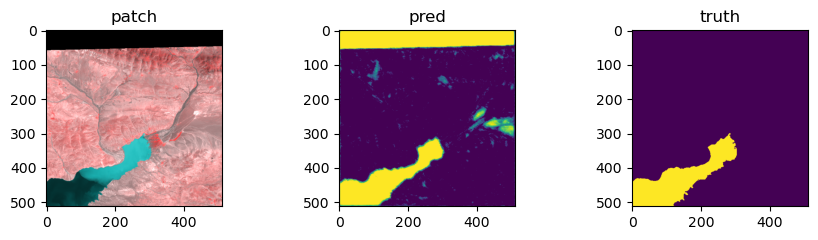

Ep1: tra-> Loss:0.460,Oa:0.846,Miou:0.743,                                 time:3.7s
Ep2: tra-> Loss:0.397,Oa:0.827,Miou:0.708,                                 time:3.8s
Ep3: tra-> Loss:0.312,Oa:0.900,Miou:0.790, val-> Loss:0.280,Oa:0.915, Miou:0.811,time:6.4s
Ep4: tra-> Loss:0.264,Oa:0.921,Miou:0.822,                                 time:3.7s
Ep5: tra-> Loss:0.241,Oa:0.911,Miou:0.808,                                 time:3.7s
Ep6: tra-> Loss:0.212,Oa:0.917,Miou:0.829, val-> Loss:0.171,Oa:0.951, Miou:0.855,time:6.3s
Ep7: tra-> Loss:0.187,Oa:0.924,Miou:0.851,                                 time:3.7s
Ep8: tra-> Loss:0.171,Oa:0.923,Miou:0.846,                                 time:3.7s
Ep9: tra-> Loss:0.164,Oa:0.917,Miou:0.850, val-> Loss:0.166,Oa:0.922, Miou:0.857,time:6.4s
Ep10: tra-> Loss:0.159,Oa:0.926,Miou:0.848,                                 time:3.7s
Ep11: tra-> Loss:0.142,Oa:0.932,Miou:0.865,                                 time:3.7s
Ep12: tra-> Loss:0.129,Oa:0.940,Miou:0.878, v

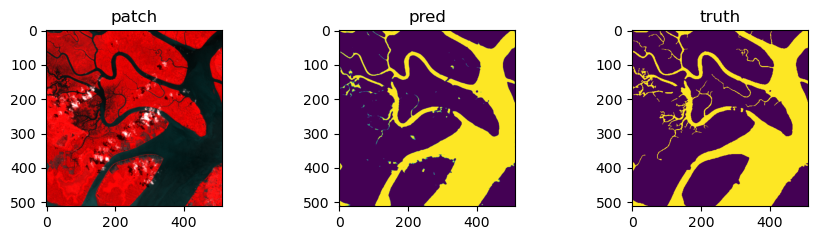

Ep21: tra-> Loss:0.097,Oa:0.944,Miou:0.895, val-> Loss:0.082,Oa:0.951, Miou:0.903,time:6.3s
Ep22: tra-> Loss:0.087,Oa:0.958,Miou:0.905,                                 time:3.7s
Ep23: tra-> Loss:0.099,Oa:0.947,Miou:0.897,                                 time:3.7s
Ep24: tra-> Loss:0.087,Oa:0.960,Miou:0.907, val-> Loss:0.074,Oa:0.953, Miou:0.907,time:6.4s
Ep25: tra-> Loss:0.089,Oa:0.953,Miou:0.905,                                 time:3.8s
Ep26: tra-> Loss:0.082,Oa:0.954,Miou:0.907,                                 time:3.7s
Ep27: tra-> Loss:0.096,Oa:0.940,Miou:0.887, val-> Loss:0.066,Oa:0.959, Miou:0.910,time:6.4s
Ep28: tra-> Loss:0.095,Oa:0.944,Miou:0.897,                                 time:3.7s
Ep29: tra-> Loss:0.080,Oa:0.961,Miou:0.913,                                 time:3.8s
Ep30: tra-> Loss:0.086,Oa:0.953,Miou:0.902, val-> Loss:0.064,Oa:0.960, Miou:0.907,time:6.4s
Ep31: tra-> Loss:0.081,Oa:0.948,Miou:0.904,                                 time:3.7s
Ep32: tra-> Loss:0.074,Oa:0.95

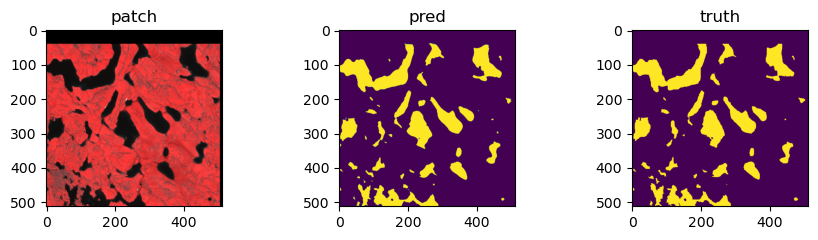

Ep41: tra-> Loss:0.066,Oa:0.967,Miou:0.929,                                 time:3.7s
Ep42: tra-> Loss:0.069,Oa:0.959,Miou:0.919, val-> Loss:0.073,Oa:0.951, Miou:0.907,time:6.4s
Ep43: tra-> Loss:0.060,Oa:0.968,Miou:0.932,                                 time:3.7s
Ep44: tra-> Loss:0.062,Oa:0.966,Miou:0.926,                                 time:3.7s
Ep45: tra-> Loss:0.067,Oa:0.962,Miou:0.918, val-> Loss:0.069,Oa:0.949, Miou:0.915,time:6.4s
Ep46: tra-> Loss:0.061,Oa:0.969,Miou:0.930,                                 time:3.7s
Ep47: tra-> Loss:0.074,Oa:0.965,Miou:0.925,                                 time:3.7s
Ep48: tra-> Loss:0.072,Oa:0.961,Miou:0.917, val-> Loss:0.073,Oa:0.952, Miou:0.909,time:6.4s
Ep49: tra-> Loss:0.064,Oa:0.964,Miou:0.927,                                 time:3.7s
Ep50: tra-> Loss:0.078,Oa:0.950,Miou:0.911,                                 time:3.6s
Ep51: tra-> Loss:0.061,Oa:0.967,Miou:0.927, val-> Loss:0.067,Oa:0.953, Miou:0.915,time:6.5s
Ep52: tra-> Loss:0.054,Oa:0.97

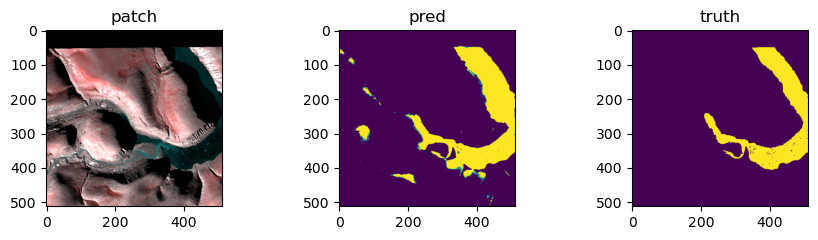

Ep61: tra-> Loss:0.055,Oa:0.970,Miou:0.932,                                 time:3.7s
Ep62: tra-> Loss:0.066,Oa:0.957,Miou:0.912,                                 time:3.7s
Ep63: tra-> Loss:0.056,Oa:0.965,Miou:0.931, val-> Loss:0.058,Oa:0.961, Miou:0.920,time:6.3s
Ep64: tra-> Loss:0.052,Oa:0.974,Miou:0.940,                                 time:3.8s
Ep65: tra-> Loss:0.051,Oa:0.972,Miou:0.939,                                 time:3.9s
Ep66: tra-> Loss:0.054,Oa:0.972,Miou:0.938, val-> Loss:0.065,Oa:0.951, Miou:0.920,time:6.4s
Ep67: tra-> Loss:0.053,Oa:0.970,Miou:0.931,                                 time:3.7s
Ep68: tra-> Loss:0.052,Oa:0.969,Miou:0.934,                                 time:3.7s
Ep69: tra-> Loss:0.058,Oa:0.965,Miou:0.927, val-> Loss:0.061,Oa:0.955, Miou:0.918,time:6.4s
Ep70: tra-> Loss:0.054,Oa:0.971,Miou:0.937,                                 time:3.7s
Ep71: tra-> Loss:0.054,Oa:0.965,Miou:0.930,                                 time:3.9s
Ep72: tra-> Loss:0.048,Oa:0.972,Miou

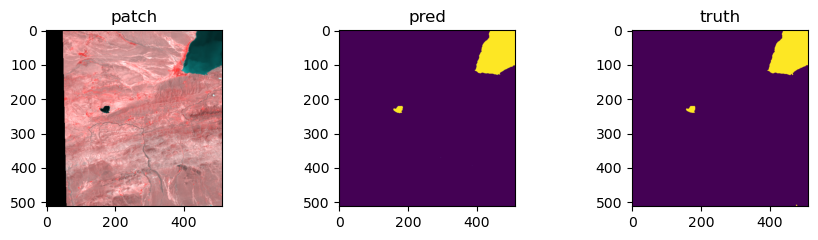

Ep81: tra-> Loss:0.046,Oa:0.975,Miou:0.943, val-> Loss:0.061,Oa:0.958, Miou:0.925,time:6.4s
Ep82: tra-> Loss:0.046,Oa:0.976,Miou:0.939,                                 time:3.7s
Ep83: tra-> Loss:0.051,Oa:0.968,Miou:0.933,                                 time:3.7s
Ep84: tra-> Loss:0.046,Oa:0.977,Miou:0.943, val-> Loss:0.053,Oa:0.963, Miou:0.928,time:6.3s
Ep85: tra-> Loss:0.047,Oa:0.972,Miou:0.935,                                 time:3.8s
Ep86: tra-> Loss:0.050,Oa:0.971,Miou:0.934,                                 time:3.7s
Ep87: tra-> Loss:0.044,Oa:0.974,Miou:0.942, val-> Loss:0.055,Oa:0.960, Miou:0.927,time:6.4s
Ep88: tra-> Loss:0.052,Oa:0.969,Miou:0.930,                                 time:3.7s
Ep89: tra-> Loss:0.068,Oa:0.964,Miou:0.928,                                 time:3.8s
Ep90: tra-> Loss:0.047,Oa:0.975,Miou:0.937, val-> Loss:0.057,Oa:0.958, Miou:0.924,time:6.4s
Ep91: tra-> Loss:0.047,Oa:0.975,Miou:0.940,                                 time:3.8s
Ep92: tra-> Loss:0.044,Oa:0.97

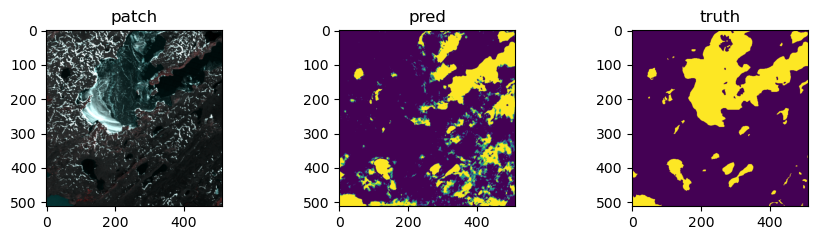

Ep101: tra-> Loss:0.044,Oa:0.976,Miou:0.938,                                 time:3.7s
Ep102: tra-> Loss:0.045,Oa:0.972,Miou:0.938, val-> Loss:0.053,Oa:0.961, Miou:0.927,time:6.5s
Ep103: tra-> Loss:0.046,Oa:0.973,Miou:0.936,                                 time:3.7s
Ep104: tra-> Loss:0.042,Oa:0.976,Miou:0.940,                                 time:3.7s
Ep105: tra-> Loss:0.041,Oa:0.975,Miou:0.942, val-> Loss:0.056,Oa:0.960, Miou:0.925,time:6.5s
Ep106: tra-> Loss:0.042,Oa:0.976,Miou:0.944,                                 time:3.7s
Ep107: tra-> Loss:0.077,Oa:0.955,Miou:0.913,                                 time:3.8s
Ep108: tra-> Loss:0.045,Oa:0.972,Miou:0.940, val-> Loss:0.052,Oa:0.964, Miou:0.925,time:6.4s
Ep109: tra-> Loss:0.045,Oa:0.976,Miou:0.942,                                 time:3.7s
Ep110: tra-> Loss:0.043,Oa:0.975,Miou:0.943,                                 time:3.8s
Ep111: tra-> Loss:0.042,Oa:0.979,Miou:0.946, val-> Loss:0.059,Oa:0.958, Miou:0.928,time:6.5s
Ep112: tra-> Loss:0

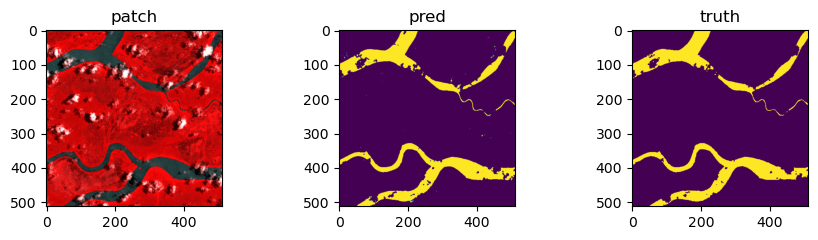

Ep121: tra-> Loss:0.040,Oa:0.978,Miou:0.946,                                 time:3.7s
Ep122: tra-> Loss:0.047,Oa:0.963,Miou:0.924,                                 time:3.8s
Ep123: tra-> Loss:0.044,Oa:0.974,Miou:0.937, val-> Loss:0.055,Oa:0.960, Miou:0.927,time:6.4s
Ep124: tra-> Loss:0.041,Oa:0.975,Miou:0.938,                                 time:3.9s
Ep125: tra-> Loss:0.036,Oa:0.979,Miou:0.947,                                 time:3.8s
Ep126: tra-> Loss:0.038,Oa:0.979,Miou:0.949, val-> Loss:0.053,Oa:0.959, Miou:0.931,time:6.7s
Ep127: tra-> Loss:0.041,Oa:0.978,Miou:0.948,                                 time:3.7s
Ep128: tra-> Loss:0.039,Oa:0.978,Miou:0.944,                                 time:3.8s
Ep129: tra-> Loss:0.046,Oa:0.974,Miou:0.937, val-> Loss:0.075,Oa:0.950, Miou:0.917,time:6.5s
Ep130: tra-> Loss:0.051,Oa:0.969,Miou:0.934,                                 time:3.9s
Ep131: tra-> Loss:0.039,Oa:0.978,Miou:0.942,                                 time:3.7s
Ep132: tra-> Loss:0.039,O

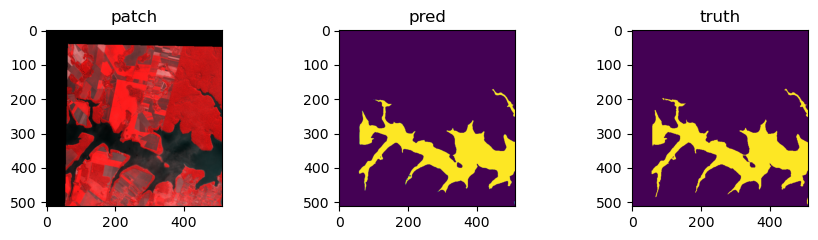

Ep141: tra-> Loss:0.049,Oa:0.969,Miou:0.937, val-> Loss:0.062,Oa:0.950, Miou:0.924,time:6.4s
Ep142: tra-> Loss:0.046,Oa:0.969,Miou:0.936,                                 time:3.8s
Ep143: tra-> Loss:0.040,Oa:0.979,Miou:0.946,                                 time:3.7s
Ep144: tra-> Loss:0.039,Oa:0.977,Miou:0.945, val-> Loss:0.057,Oa:0.955, Miou:0.927,time:6.5s
Ep145: tra-> Loss:0.041,Oa:0.980,Miou:0.946,                                 time:3.8s
Ep146: tra-> Loss:0.041,Oa:0.974,Miou:0.940,                                 time:3.7s
Ep147: tra-> Loss:0.038,Oa:0.978,Miou:0.944, val-> Loss:0.049,Oa:0.963, Miou:0.931,time:6.5s
Ep148: tra-> Loss:0.034,Oa:0.978,Miou:0.951,                                 time:3.7s
Ep149: tra-> Loss:0.039,Oa:0.972,Miou:0.940,                                 time:3.7s
Ep150: tra-> Loss:0.044,Oa:0.973,Miou:0.936, val-> Loss:0.046,Oa:0.967, Miou:0.934,time:6.4s
Ep151: tra-> Loss:0.039,Oa:0.980,Miou:0.952,                                 time:3.7s
Ep152: tra-> Loss:0

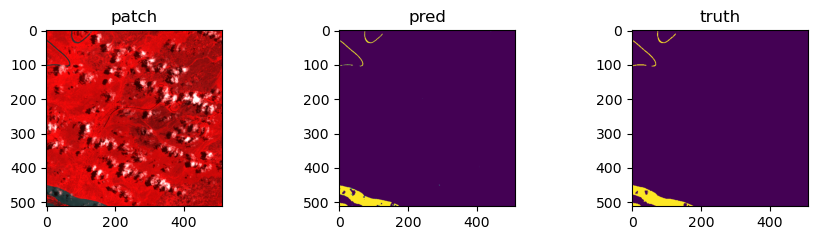

Ep161: tra-> Loss:0.038,Oa:0.980,Miou:0.947,                                 time:3.7s
Ep162: tra-> Loss:0.038,Oa:0.980,Miou:0.949, val-> Loss:0.049,Oa:0.968, Miou:0.930,time:6.4s
Ep163: tra-> Loss:0.040,Oa:0.975,Miou:0.945,                                 time:3.7s
Ep164: tra-> Loss:0.036,Oa:0.982,Miou:0.951,                                 time:3.8s
Ep165: tra-> Loss:0.035,Oa:0.982,Miou:0.956, val-> Loss:0.047,Oa:0.964, Miou:0.935,time:6.4s
Ep166: tra-> Loss:0.035,Oa:0.982,Miou:0.953,                                 time:3.8s
Ep167: tra-> Loss:0.034,Oa:0.981,Miou:0.949,                                 time:3.7s
Ep168: tra-> Loss:0.039,Oa:0.979,Miou:0.948, val-> Loss:0.052,Oa:0.963, Miou:0.934,time:6.5s
Ep169: tra-> Loss:0.036,Oa:0.981,Miou:0.952,                                 time:3.7s
Ep170: tra-> Loss:0.034,Oa:0.980,Miou:0.953,                                 time:3.7s
Ep171: tra-> Loss:0.038,Oa:0.978,Miou:0.947, val-> Loss:0.047,Oa:0.966, Miou:0.934,time:6.4s
Ep172: tra-> Loss:0

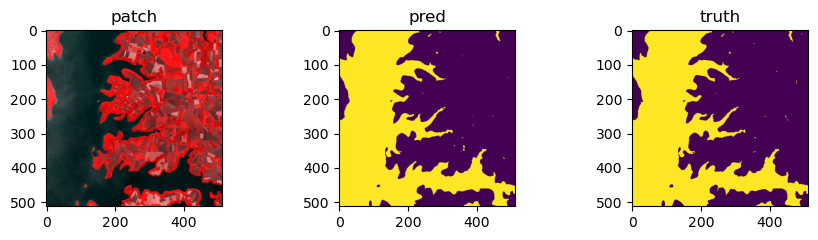

Ep181: tra-> Loss:0.035,Oa:0.980,Miou:0.949,                                 time:3.7s
Ep182: tra-> Loss:0.042,Oa:0.975,Miou:0.944,                                 time:3.8s
Ep183: tra-> Loss:0.039,Oa:0.974,Miou:0.944, val-> Loss:0.047,Oa:0.966, Miou:0.935,time:6.4s
Ep184: tra-> Loss:0.035,Oa:0.978,Miou:0.949,                                 time:3.7s
Ep185: tra-> Loss:0.034,Oa:0.982,Miou:0.953,                                 time:3.7s
Ep186: tra-> Loss:0.036,Oa:0.980,Miou:0.950, val-> Loss:0.044,Oa:0.969, Miou:0.936,time:6.4s
Ep187: tra-> Loss:0.038,Oa:0.973,Miou:0.938,                                 time:3.7s
Ep188: tra-> Loss:0.033,Oa:0.976,Miou:0.947,                                 time:3.7s
Ep189: tra-> Loss:0.033,Oa:0.982,Miou:0.953, val-> Loss:0.046,Oa:0.965, Miou:0.937,time:6.5s
Ep190: tra-> Loss:0.037,Oa:0.979,Miou:0.945,                                 time:3.7s
Ep191: tra-> Loss:0.037,Oa:0.978,Miou:0.948,                                 time:3.7s
Ep192: tra-> Loss:0.037,O

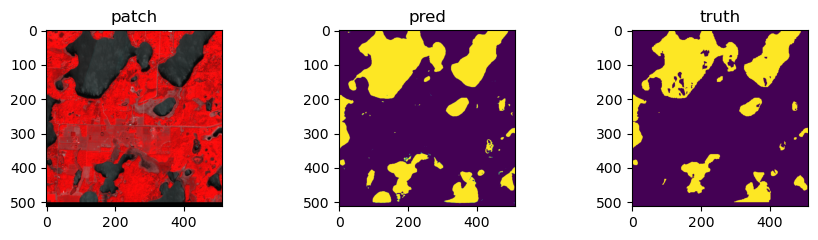

Ep201: tra-> Loss:0.046,Oa:0.975,Miou:0.943, val-> Loss:0.046,Oa:0.965, Miou:0.937,time:6.5s
Ep202: tra-> Loss:0.036,Oa:0.977,Miou:0.948,                                 time:3.8s
Ep203: tra-> Loss:0.036,Oa:0.982,Miou:0.954,                                 time:3.7s
Ep204: tra-> Loss:0.037,Oa:0.980,Miou:0.951, val-> Loss:0.040,Oa:0.973, Miou:0.936,time:6.4s
Ep205: tra-> Loss:0.038,Oa:0.980,Miou:0.948,                                 time:3.7s
Ep206: tra-> Loss:0.037,Oa:0.970,Miou:0.937,                                 time:3.8s
Ep207: tra-> Loss:0.038,Oa:0.978,Miou:0.942, val-> Loss:0.052,Oa:0.960, Miou:0.932,time:6.5s
Ep208: tra-> Loss:0.031,Oa:0.982,Miou:0.954,                                 time:3.7s
Ep209: tra-> Loss:0.031,Oa:0.983,Miou:0.959,                                 time:3.6s
Ep210: tra-> Loss:0.038,Oa:0.980,Miou:0.947, val-> Loss:0.047,Oa:0.969, Miou:0.933,time:6.4s
Ep211: tra-> Loss:0.035,Oa:0.981,Miou:0.951,                                 time:3.7s
Ep212: tra-> Loss:0

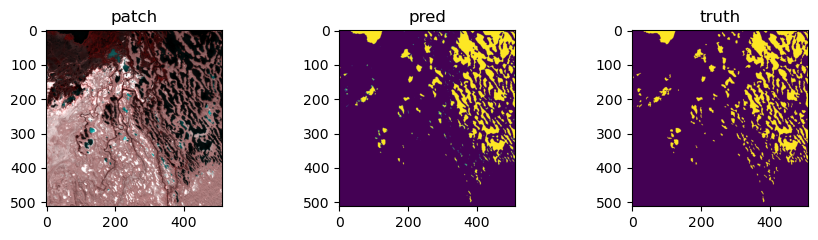

Ep221: tra-> Loss:0.035,Oa:0.979,Miou:0.949,                                 time:3.7s
Ep222: tra-> Loss:0.035,Oa:0.980,Miou:0.950, val-> Loss:0.049,Oa:0.970, Miou:0.935,time:6.3s
Ep223: tra-> Loss:0.033,Oa:0.982,Miou:0.949,                                 time:3.7s
Ep224: tra-> Loss:0.034,Oa:0.975,Miou:0.945,                                 time:3.7s
Ep225: tra-> Loss:0.042,Oa:0.975,Miou:0.944, val-> Loss:0.050,Oa:0.963, Miou:0.933,time:6.4s
Ep226: tra-> Loss:0.036,Oa:0.979,Miou:0.951,                                 time:3.8s
Ep227: tra-> Loss:0.033,Oa:0.982,Miou:0.954,                                 time:3.7s
Ep228: tra-> Loss:0.036,Oa:0.981,Miou:0.953, val-> Loss:0.042,Oa:0.968, Miou:0.940,time:6.4s
Ep229: tra-> Loss:0.034,Oa:0.983,Miou:0.955,                                 time:3.7s
Ep230: tra-> Loss:0.037,Oa:0.978,Miou:0.945,                                 time:3.7s
Ep231: tra-> Loss:0.034,Oa:0.982,Miou:0.948, val-> Loss:0.039,Oa:0.970, Miou:0.941,time:6.4s
Ep232: tra-> Loss:0

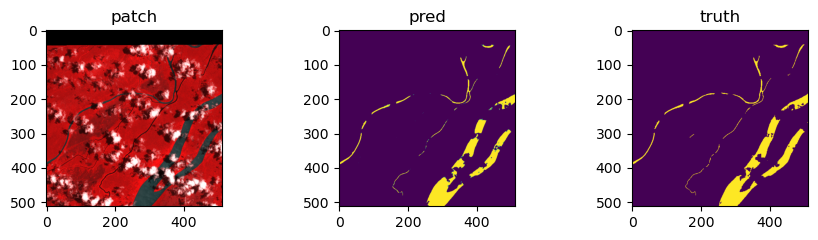

Ep241: tra-> Loss:0.035,Oa:0.979,Miou:0.949,                                 time:3.8s
Ep242: tra-> Loss:0.034,Oa:0.980,Miou:0.949,                                 time:3.7s
Ep243: tra-> Loss:0.039,Oa:0.976,Miou:0.941, val-> Loss:0.051,Oa:0.962, Miou:0.934,time:6.6s
Ep244: tra-> Loss:0.031,Oa:0.982,Miou:0.955,                                 time:3.7s
Ep245: tra-> Loss:0.035,Oa:0.971,Miou:0.941,                                 time:3.7s
Ep246: tra-> Loss:0.032,Oa:0.981,Miou:0.952, val-> Loss:0.046,Oa:0.969, Miou:0.936,time:6.4s
Ep247: tra-> Loss:0.034,Oa:0.980,Miou:0.948,                                 time:3.7s
Ep248: tra-> Loss:0.031,Oa:0.981,Miou:0.951,                                 time:3.8s
Ep249: tra-> Loss:0.036,Oa:0.978,Miou:0.946, val-> Loss:0.047,Oa:0.968, Miou:0.933,time:6.4s
Ep250: tra-> Loss:0.034,Oa:0.980,Miou:0.952,                                 time:3.8s
Ep251: tra-> Loss:0.035,Oa:0.978,Miou:0.950,                                 time:3.7s
Ep252: tra-> Loss:0.030,O

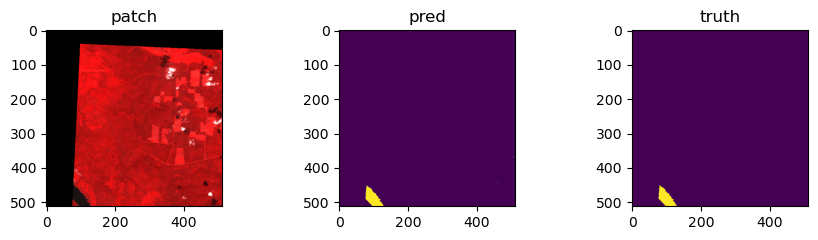

Ep261: tra-> Loss:0.036,Oa:0.982,Miou:0.952, val-> Loss:0.049,Oa:0.968, Miou:0.936,time:6.4s
Ep262: tra-> Loss:0.032,Oa:0.982,Miou:0.956,                                 time:3.7s
Ep263: tra-> Loss:0.032,Oa:0.979,Miou:0.948,                                 time:3.7s
Ep264: tra-> Loss:0.033,Oa:0.981,Miou:0.955, val-> Loss:0.043,Oa:0.969, Miou:0.940,time:6.3s
Ep265: tra-> Loss:0.031,Oa:0.983,Miou:0.953,                                 time:3.7s
Ep266: tra-> Loss:0.030,Oa:0.984,Miou:0.957,                                 time:3.7s
Ep267: tra-> Loss:0.041,Oa:0.973,Miou:0.944, val-> Loss:0.052,Oa:0.964, Miou:0.933,time:6.3s
Ep268: tra-> Loss:0.044,Oa:0.978,Miou:0.941,                                 time:3.7s
Ep269: tra-> Loss:0.033,Oa:0.982,Miou:0.952,                                 time:3.7s
Ep270: tra-> Loss:0.033,Oa:0.981,Miou:0.953, val-> Loss:0.042,Oa:0.968, Miou:0.940,time:6.3s
Ep271: tra-> Loss:0.034,Oa:0.978,Miou:0.949,                                 time:3.7s
Ep272: tra-> Loss:0

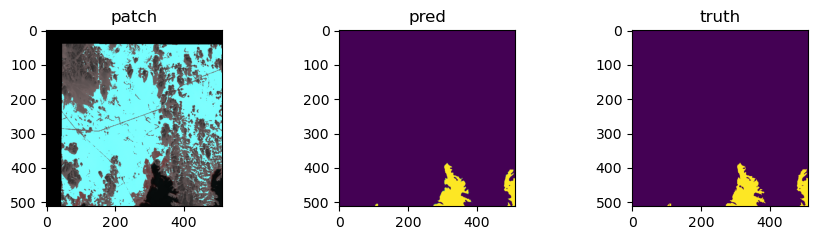

Ep281: tra-> Loss:0.034,Oa:0.982,Miou:0.954,                                 time:3.8s
Ep282: tra-> Loss:0.034,Oa:0.981,Miou:0.951, val-> Loss:0.049,Oa:0.966, Miou:0.933,time:6.4s
Ep283: tra-> Loss:0.036,Oa:0.979,Miou:0.949,                                 time:3.7s
Ep284: tra-> Loss:0.031,Oa:0.983,Miou:0.954,                                 time:3.8s
Ep285: tra-> Loss:0.032,Oa:0.982,Miou:0.954, val-> Loss:0.041,Oa:0.970, Miou:0.939,time:6.4s
Ep286: tra-> Loss:0.030,Oa:0.983,Miou:0.957,                                 time:3.7s
Ep287: tra-> Loss:0.031,Oa:0.981,Miou:0.954,                                 time:3.7s
Ep288: tra-> Loss:0.031,Oa:0.982,Miou:0.953, val-> Loss:0.043,Oa:0.967, Miou:0.940,time:6.4s
Ep289: tra-> Loss:0.032,Oa:0.981,Miou:0.955,                                 time:3.7s
Ep290: tra-> Loss:0.033,Oa:0.982,Miou:0.955,                                 time:3.7s
Ep291: tra-> Loss:0.033,Oa:0.982,Miou:0.953, val-> Loss:0.042,Oa:0.972, Miou:0.938,time:6.4s
Ep292: tra-> Loss:0

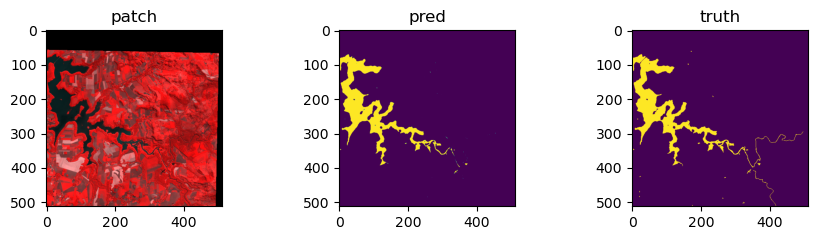

Ep301: tra-> Loss:0.033,Oa:0.982,Miou:0.952,                                 time:3.7s
Ep302: tra-> Loss:0.035,Oa:0.982,Miou:0.952,                                 time:3.7s
Ep303: tra-> Loss:0.032,Oa:0.983,Miou:0.960, val-> Loss:0.042,Oa:0.973, Miou:0.939,time:6.4s
Ep304: tra-> Loss:0.029,Oa:0.982,Miou:0.956,                                 time:3.7s
Ep305: tra-> Loss:0.033,Oa:0.983,Miou:0.956,                                 time:3.7s
Ep306: tra-> Loss:0.031,Oa:0.981,Miou:0.956, val-> Loss:0.048,Oa:0.964, Miou:0.935,time:6.4s
Ep307: tra-> Loss:0.029,Oa:0.984,Miou:0.956,                                 time:3.8s
Ep308: tra-> Loss:0.031,Oa:0.983,Miou:0.954,                                 time:3.8s
Ep309: tra-> Loss:0.031,Oa:0.981,Miou:0.956, val-> Loss:0.042,Oa:0.970, Miou:0.937,time:6.4s
Ep310: tra-> Loss:0.031,Oa:0.980,Miou:0.954,                                 time:3.8s
Ep311: tra-> Loss:0.032,Oa:0.981,Miou:0.950,                                 time:3.7s
Ep312: tra-> Loss:0.032,O

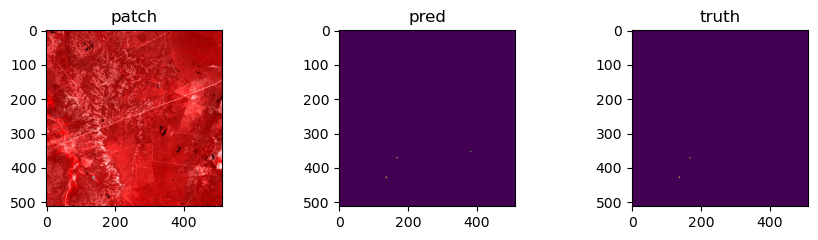

Ep321: tra-> Loss:0.034,Oa:0.980,Miou:0.955, val-> Loss:0.048,Oa:0.962, Miou:0.936,time:6.4s
Ep322: tra-> Loss:0.032,Oa:0.983,Miou:0.956,                                 time:3.7s
Ep323: tra-> Loss:0.032,Oa:0.978,Miou:0.951,                                 time:3.8s
Ep324: tra-> Loss:0.031,Oa:0.980,Miou:0.949, val-> Loss:0.039,Oa:0.971, Miou:0.941,time:6.4s
Ep325: tra-> Loss:0.028,Oa:0.982,Miou:0.956,                                 time:3.7s
Ep326: tra-> Loss:0.032,Oa:0.981,Miou:0.951,                                 time:3.8s
Ep327: tra-> Loss:0.036,Oa:0.980,Miou:0.952, val-> Loss:0.041,Oa:0.973, Miou:0.938,time:6.4s
Ep328: tra-> Loss:0.034,Oa:0.982,Miou:0.954,                                 time:3.7s
Ep329: tra-> Loss:0.029,Oa:0.982,Miou:0.958,                                 time:3.8s
Ep330: tra-> Loss:0.030,Oa:0.983,Miou:0.953, val-> Loss:0.041,Oa:0.970, Miou:0.941,time:6.3s
Ep331: tra-> Loss:0.029,Oa:0.980,Miou:0.955,                                 time:3.8s
Ep332: tra-> Loss:0

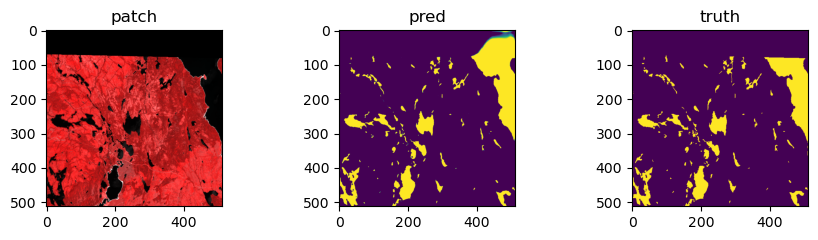

Ep341: tra-> Loss:0.030,Oa:0.982,Miou:0.953,                                 time:3.7s
Ep342: tra-> Loss:0.031,Oa:0.981,Miou:0.958, val-> Loss:0.041,Oa:0.969, Miou:0.940,time:6.4s
Ep343: tra-> Loss:0.029,Oa:0.982,Miou:0.953,                                 time:3.7s
Ep344: tra-> Loss:0.027,Oa:0.985,Miou:0.963,                                 time:3.7s
Ep345: tra-> Loss:0.029,Oa:0.984,Miou:0.961, val-> Loss:0.043,Oa:0.969, Miou:0.938,time:6.4s
Ep346: tra-> Loss:0.046,Oa:0.968,Miou:0.937,                                 time:3.7s
Ep347: tra-> Loss:0.031,Oa:0.983,Miou:0.958,                                 time:3.7s
Ep348: tra-> Loss:0.034,Oa:0.981,Miou:0.951, val-> Loss:0.042,Oa:0.968, Miou:0.940,time:6.4s
Ep349: tra-> Loss:0.030,Oa:0.982,Miou:0.957,                                 time:3.7s
Ep350: tra-> Loss:0.029,Oa:0.983,Miou:0.957,                                 time:3.7s
Ep351: tra-> Loss:0.031,Oa:0.983,Miou:0.957, val-> Loss:0.041,Oa:0.969, Miou:0.940,time:6.3s
Ep352: tra-> Loss:0

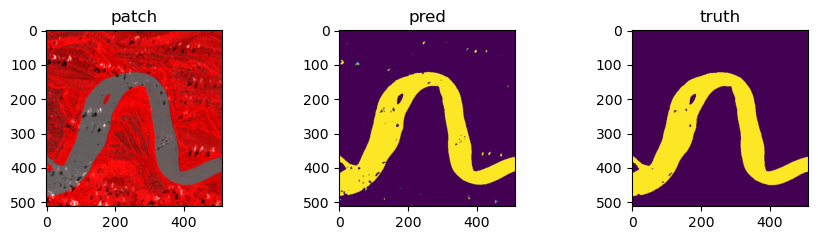

Ep361: tra-> Loss:0.030,Oa:0.981,Miou:0.955,                                 time:3.8s
Ep362: tra-> Loss:0.030,Oa:0.980,Miou:0.950,                                 time:3.7s
Ep363: tra-> Loss:0.030,Oa:0.983,Miou:0.957, val-> Loss:0.042,Oa:0.968, Miou:0.940,time:6.4s
Ep364: tra-> Loss:0.027,Oa:0.983,Miou:0.961,                                 time:3.6s
Ep365: tra-> Loss:0.028,Oa:0.984,Miou:0.962,                                 time:3.6s
Ep366: tra-> Loss:0.033,Oa:0.976,Miou:0.945, val-> Loss:0.047,Oa:0.967, Miou:0.935,time:6.4s
Ep367: tra-> Loss:0.031,Oa:0.981,Miou:0.951,                                 time:3.7s
Ep368: tra-> Loss:0.030,Oa:0.983,Miou:0.957,                                 time:3.7s
Ep369: tra-> Loss:0.031,Oa:0.984,Miou:0.958, val-> Loss:0.044,Oa:0.967, Miou:0.939,time:6.4s
Ep370: tra-> Loss:0.029,Oa:0.983,Miou:0.959,                                 time:3.7s
Ep371: tra-> Loss:0.040,Oa:0.976,Miou:0.946,                                 time:3.7s
Ep372: tra-> Loss:0.033,O

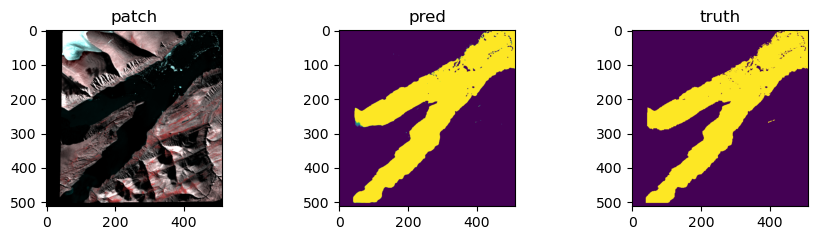

Ep381: tra-> Loss:0.027,Oa:0.982,Miou:0.956, val-> Loss:0.041,Oa:0.968, Miou:0.941,time:6.5s
Ep382: tra-> Loss:0.032,Oa:0.981,Miou:0.952,                                 time:3.7s
Ep383: tra-> Loss:0.032,Oa:0.982,Miou:0.956,                                 time:3.8s
Ep384: tra-> Loss:0.028,Oa:0.983,Miou:0.958, val-> Loss:0.040,Oa:0.971, Miou:0.942,time:6.4s
Ep385: tra-> Loss:0.031,Oa:0.977,Miou:0.947,                                 time:3.7s
Ep386: tra-> Loss:0.029,Oa:0.979,Miou:0.950,                                 time:3.8s
Ep387: tra-> Loss:0.028,Oa:0.985,Miou:0.960, val-> Loss:0.038,Oa:0.974, Miou:0.943,time:6.4s
Ep388: tra-> Loss:0.028,Oa:0.984,Miou:0.957,                                 time:3.7s
Ep389: tra-> Loss:0.027,Oa:0.984,Miou:0.960,                                 time:3.7s
Ep390: tra-> Loss:0.033,Oa:0.981,Miou:0.953, val-> Loss:0.041,Oa:0.970, Miou:0.942,time:6.4s
Ep391: tra-> Loss:0.031,Oa:0.980,Miou:0.954,                                 time:3.7s
Ep392: tra-> Loss:0

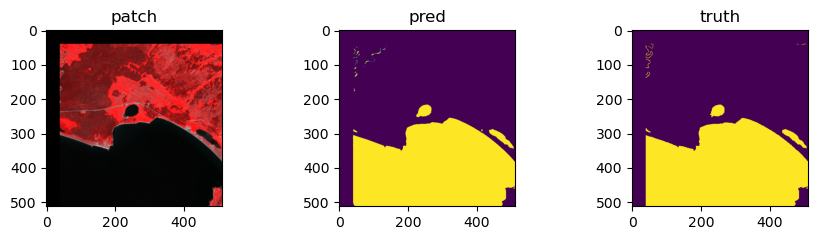

Ep401: tra-> Loss:0.025,Oa:0.985,Miou:0.963,                                 time:3.8s
Ep402: tra-> Loss:0.027,Oa:0.982,Miou:0.957, val-> Loss:0.038,Oa:0.973, Miou:0.943,time:6.4s
Ep403: tra-> Loss:0.028,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep404: tra-> Loss:0.029,Oa:0.982,Miou:0.954,                                 time:3.7s
Ep405: tra-> Loss:0.027,Oa:0.985,Miou:0.963, val-> Loss:0.047,Oa:0.964, Miou:0.932,time:6.3s
Ep406: tra-> Loss:0.030,Oa:0.984,Miou:0.959,                                 time:3.7s
Ep407: tra-> Loss:0.029,Oa:0.980,Miou:0.954,                                 time:3.7s
Ep408: tra-> Loss:0.028,Oa:0.983,Miou:0.955, val-> Loss:0.047,Oa:0.962, Miou:0.937,time:6.3s
Ep409: tra-> Loss:0.029,Oa:0.983,Miou:0.955,                                 time:3.7s
Ep410: tra-> Loss:0.030,Oa:0.983,Miou:0.956,                                 time:3.7s
Ep411: tra-> Loss:0.030,Oa:0.984,Miou:0.958, val-> Loss:0.042,Oa:0.968, Miou:0.939,time:6.4s
Ep412: tra-> Loss:0

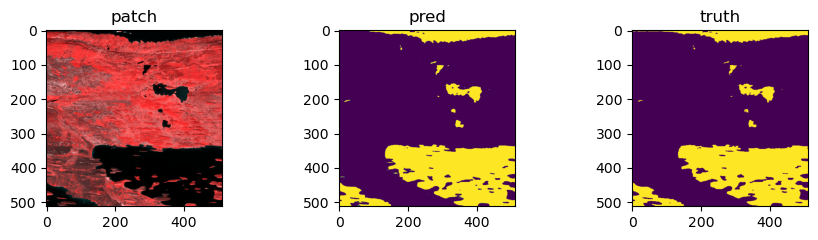

Ep421: tra-> Loss:0.028,Oa:0.982,Miou:0.956,                                 time:3.8s
Ep422: tra-> Loss:0.027,Oa:0.985,Miou:0.957,                                 time:3.7s
Ep423: tra-> Loss:0.027,Oa:0.985,Miou:0.963, val-> Loss:0.040,Oa:0.970, Miou:0.943,time:6.4s
Ep424: tra-> Loss:0.030,Oa:0.982,Miou:0.954,                                 time:3.7s
Ep425: tra-> Loss:0.028,Oa:0.983,Miou:0.958,                                 time:3.6s
Ep426: tra-> Loss:0.028,Oa:0.984,Miou:0.959, val-> Loss:0.038,Oa:0.973, Miou:0.943,time:6.4s
Ep427: tra-> Loss:0.030,Oa:0.983,Miou:0.956,                                 time:3.8s
Ep428: tra-> Loss:0.028,Oa:0.986,Miou:0.964,                                 time:3.7s
Ep429: tra-> Loss:0.031,Oa:0.982,Miou:0.954, val-> Loss:0.049,Oa:0.967, Miou:0.937,time:6.3s
Ep430: tra-> Loss:0.034,Oa:0.979,Miou:0.954,                                 time:3.7s
Ep431: tra-> Loss:0.034,Oa:0.982,Miou:0.949,                                 time:3.7s
Ep432: tra-> Loss:0.030,O

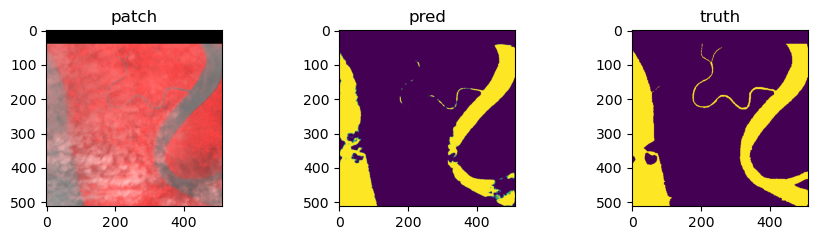

Ep441: tra-> Loss:0.027,Oa:0.983,Miou:0.955, val-> Loss:0.053,Oa:0.961, Miou:0.932,time:6.4s
Ep442: tra-> Loss:0.027,Oa:0.985,Miou:0.963,                                 time:3.7s
Ep443: tra-> Loss:0.029,Oa:0.984,Miou:0.957,                                 time:3.7s
Ep444: tra-> Loss:0.028,Oa:0.980,Miou:0.957, val-> Loss:0.039,Oa:0.974, Miou:0.942,time:6.4s
Ep445: tra-> Loss:0.030,Oa:0.982,Miou:0.956,                                 time:3.6s
Ep446: tra-> Loss:0.027,Oa:0.986,Miou:0.962,                                 time:3.7s
Ep447: tra-> Loss:0.026,Oa:0.980,Miou:0.955, val-> Loss:0.040,Oa:0.972, Miou:0.941,time:6.4s
Ep448: tra-> Loss:0.029,Oa:0.984,Miou:0.959,                                 time:3.7s
Ep449: tra-> Loss:0.028,Oa:0.985,Miou:0.960,                                 time:3.7s
Ep450: tra-> Loss:0.027,Oa:0.985,Miou:0.962, val-> Loss:0.045,Oa:0.966, Miou:0.941,time:6.4s
Ep451: tra-> Loss:0.029,Oa:0.982,Miou:0.954,                                 time:3.7s
Ep452: tra-> Loss:0

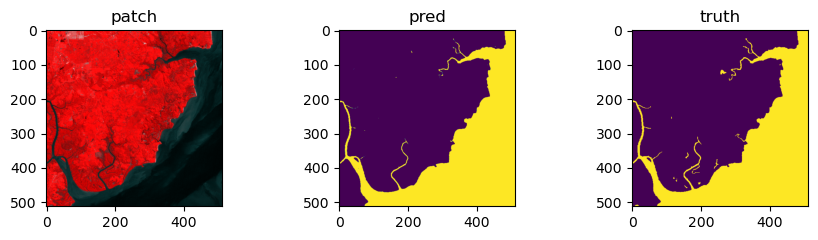

Ep461: tra-> Loss:0.030,Oa:0.982,Miou:0.956,                                 time:3.7s
Ep462: tra-> Loss:0.030,Oa:0.981,Miou:0.954, val-> Loss:0.041,Oa:0.969, Miou:0.944,time:6.4s
Ep463: tra-> Loss:0.031,Oa:0.982,Miou:0.958,                                 time:3.7s
Ep464: tra-> Loss:0.028,Oa:0.985,Miou:0.960,                                 time:3.7s
Ep465: tra-> Loss:0.030,Oa:0.983,Miou:0.958, val-> Loss:0.045,Oa:0.968, Miou:0.942,time:6.3s
Ep466: tra-> Loss:0.029,Oa:0.983,Miou:0.956,                                 time:3.7s
Ep467: tra-> Loss:0.027,Oa:0.984,Miou:0.961,                                 time:3.8s
Ep468: tra-> Loss:0.028,Oa:0.984,Miou:0.958, val-> Loss:0.042,Oa:0.969, Miou:0.943,time:6.4s
Ep469: tra-> Loss:0.027,Oa:0.986,Miou:0.964,                                 time:3.7s
Ep470: tra-> Loss:0.026,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep471: tra-> Loss:0.025,Oa:0.986,Miou:0.963, val-> Loss:0.040,Oa:0.970, Miou:0.943,time:6.4s
Ep472: tra-> Loss:0

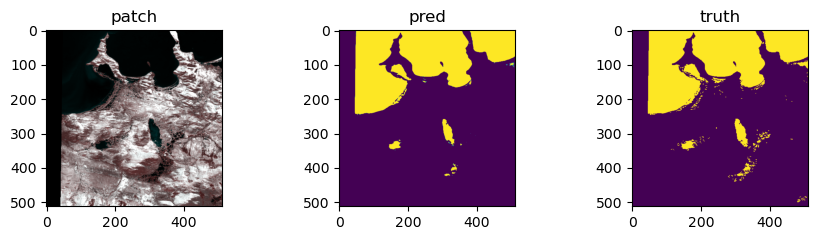

Ep481: tra-> Loss:0.028,Oa:0.983,Miou:0.956,                                 time:3.8s
Ep482: tra-> Loss:0.030,Oa:0.983,Miou:0.958,                                 time:3.7s
Ep483: tra-> Loss:0.029,Oa:0.982,Miou:0.958, val-> Loss:0.049,Oa:0.965, Miou:0.940,time:6.4s
Ep484: tra-> Loss:0.028,Oa:0.983,Miou:0.955,                                 time:3.8s
Ep485: tra-> Loss:0.027,Oa:0.984,Miou:0.961,                                 time:3.7s
Ep486: tra-> Loss:0.028,Oa:0.982,Miou:0.957, val-> Loss:0.039,Oa:0.974, Miou:0.941,time:6.4s
Ep487: tra-> Loss:0.030,Oa:0.983,Miou:0.957,                                 time:3.7s
Ep488: tra-> Loss:0.030,Oa:0.982,Miou:0.956,                                 time:3.7s
Ep489: tra-> Loss:0.028,Oa:0.984,Miou:0.960, val-> Loss:0.038,Oa:0.972, Miou:0.944,time:6.4s
Ep490: tra-> Loss:0.029,Oa:0.984,Miou:0.960,                                 time:3.7s
Ep491: tra-> Loss:0.027,Oa:0.983,Miou:0.957,                                 time:3.6s
Ep492: tra-> Loss:0.029,O

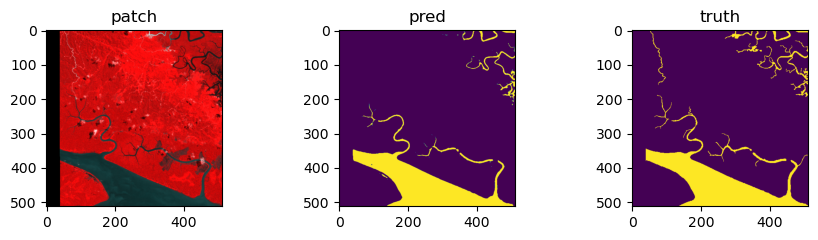

Ep501: tra-> Loss:0.030,Oa:0.984,Miou:0.957, val-> Loss:0.039,Oa:0.970, Miou:0.943,time:6.4s
Ep502: tra-> Loss:0.028,Oa:0.983,Miou:0.954,                                 time:3.8s
Ep503: tra-> Loss:0.026,Oa:0.985,Miou:0.963,                                 time:3.6s
Ep504: tra-> Loss:0.028,Oa:0.985,Miou:0.960, val-> Loss:0.038,Oa:0.974, Miou:0.943,time:6.4s
Ep505: tra-> Loss:0.026,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep506: tra-> Loss:0.032,Oa:0.981,Miou:0.951,                                 time:3.7s
Ep507: tra-> Loss:0.027,Oa:0.983,Miou:0.960, val-> Loss:0.049,Oa:0.962, Miou:0.938,time:6.4s
Ep508: tra-> Loss:0.029,Oa:0.980,Miou:0.954,                                 time:3.7s
Ep509: tra-> Loss:0.027,Oa:0.985,Miou:0.964,                                 time:3.7s
Ep510: tra-> Loss:0.028,Oa:0.985,Miou:0.962, val-> Loss:0.039,Oa:0.972, Miou:0.943,time:6.4s
Ep511: tra-> Loss:0.030,Oa:0.979,Miou:0.952,                                 time:3.7s
Ep512: tra-> Loss:0

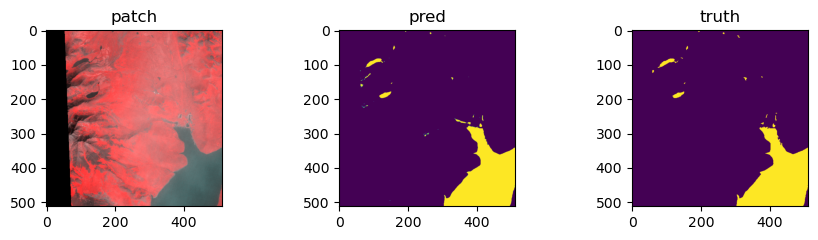

Ep521: tra-> Loss:0.028,Oa:0.984,Miou:0.961,                                 time:3.7s
Ep522: tra-> Loss:0.027,Oa:0.984,Miou:0.957, val-> Loss:0.043,Oa:0.967, Miou:0.941,time:6.4s
Ep523: tra-> Loss:0.026,Oa:0.986,Miou:0.964,                                 time:3.6s
Ep524: tra-> Loss:0.031,Oa:0.983,Miou:0.957,                                 time:3.8s
Ep525: tra-> Loss:0.025,Oa:0.986,Miou:0.965, val-> Loss:0.046,Oa:0.963, Miou:0.940,time:6.4s
Ep526: tra-> Loss:0.026,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep527: tra-> Loss:0.025,Oa:0.984,Miou:0.961,                                 time:3.7s
Ep528: tra-> Loss:0.030,Oa:0.982,Miou:0.956, val-> Loss:0.055,Oa:0.961, Miou:0.936,time:6.3s
Ep529: tra-> Loss:0.027,Oa:0.984,Miou:0.962,                                 time:3.7s
Ep530: tra-> Loss:0.027,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep531: tra-> Loss:0.026,Oa:0.984,Miou:0.959, val-> Loss:0.042,Oa:0.971, Miou:0.938,time:6.4s
Ep532: tra-> Loss:0

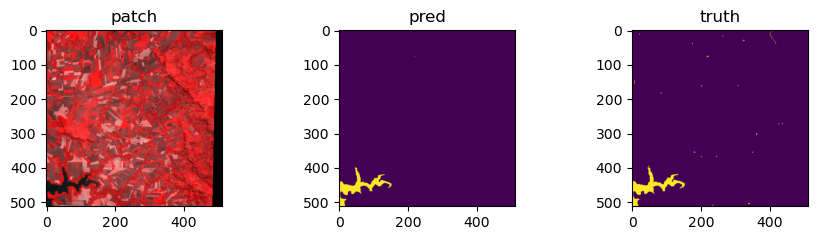

Ep541: tra-> Loss:0.027,Oa:0.986,Miou:0.961,                                 time:3.7s
Ep542: tra-> Loss:0.027,Oa:0.982,Miou:0.956,                                 time:3.6s
Ep543: tra-> Loss:0.027,Oa:0.984,Miou:0.959, val-> Loss:0.043,Oa:0.971, Miou:0.940,time:6.4s
Ep544: tra-> Loss:0.026,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep545: tra-> Loss:0.026,Oa:0.984,Miou:0.956,                                 time:3.7s
Ep546: tra-> Loss:0.028,Oa:0.984,Miou:0.958, val-> Loss:0.045,Oa:0.970, Miou:0.938,time:6.4s
Ep547: tra-> Loss:0.027,Oa:0.984,Miou:0.962,                                 time:3.7s
Ep548: tra-> Loss:0.026,Oa:0.984,Miou:0.958,                                 time:3.7s
Ep549: tra-> Loss:0.027,Oa:0.984,Miou:0.958, val-> Loss:0.040,Oa:0.972, Miou:0.942,time:6.4s
Ep550: tra-> Loss:0.026,Oa:0.984,Miou:0.958,                                 time:3.7s
Ep551: tra-> Loss:0.028,Oa:0.982,Miou:0.955,                                 time:3.7s
Ep552: tra-> Loss:0.025,O

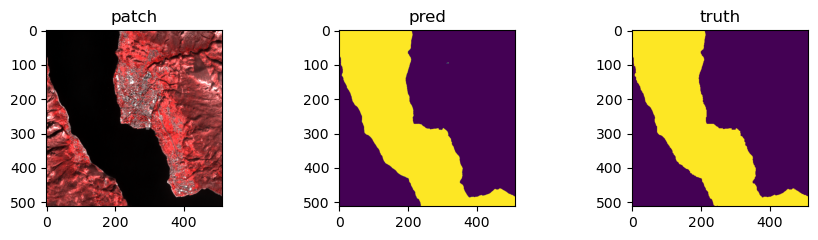

Ep561: tra-> Loss:0.028,Oa:0.983,Miou:0.956, val-> Loss:0.039,Oa:0.972, Miou:0.939,time:6.3s
Ep562: tra-> Loss:0.028,Oa:0.984,Miou:0.961,                                 time:3.6s
Ep563: tra-> Loss:0.027,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep564: tra-> Loss:0.027,Oa:0.985,Miou:0.963, val-> Loss:0.042,Oa:0.974, Miou:0.940,time:6.4s
Ep565: tra-> Loss:0.027,Oa:0.983,Miou:0.956,                                 time:3.7s
Ep566: tra-> Loss:0.027,Oa:0.984,Miou:0.959,                                 time:3.7s
Ep567: tra-> Loss:0.025,Oa:0.984,Miou:0.961, val-> Loss:0.042,Oa:0.967, Miou:0.943,time:6.4s
Ep568: tra-> Loss:0.028,Oa:0.983,Miou:0.960,                                 time:3.7s
Ep569: tra-> Loss:0.027,Oa:0.983,Miou:0.954,                                 time:3.7s
Ep570: tra-> Loss:0.025,Oa:0.985,Miou:0.964, val-> Loss:0.045,Oa:0.970, Miou:0.937,time:6.3s
Ep571: tra-> Loss:0.026,Oa:0.984,Miou:0.959,                                 time:3.7s
Ep572: tra-> Loss:0

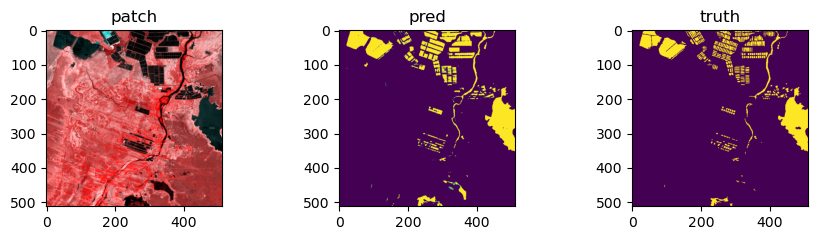

Ep581: tra-> Loss:0.029,Oa:0.985,Miou:0.960,                                 time:3.7s
Ep582: tra-> Loss:0.028,Oa:0.983,Miou:0.958, val-> Loss:0.047,Oa:0.968, Miou:0.940,time:6.4s
Ep583: tra-> Loss:0.025,Oa:0.987,Miou:0.966,                                 time:3.8s
Ep584: tra-> Loss:0.028,Oa:0.984,Miou:0.959,                                 time:3.8s
Ep585: tra-> Loss:0.030,Oa:0.983,Miou:0.958, val-> Loss:0.054,Oa:0.963, Miou:0.935,time:6.4s
Ep586: tra-> Loss:0.030,Oa:0.981,Miou:0.953,                                 time:3.7s
Ep587: tra-> Loss:0.027,Oa:0.986,Miou:0.961,                                 time:3.7s
Ep588: tra-> Loss:0.028,Oa:0.984,Miou:0.960, val-> Loss:0.039,Oa:0.973, Miou:0.942,time:6.4s
Ep589: tra-> Loss:0.026,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep590: tra-> Loss:0.025,Oa:0.987,Miou:0.966,                                 time:3.7s
Ep591: tra-> Loss:0.026,Oa:0.984,Miou:0.963, val-> Loss:0.043,Oa:0.975, Miou:0.942,time:6.3s
Ep592: tra-> Loss:0

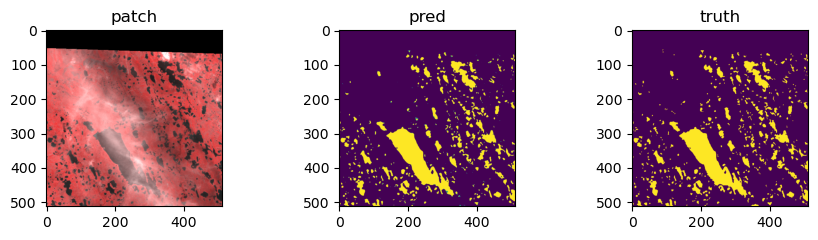

Ep601: tra-> Loss:0.026,Oa:0.982,Miou:0.958,                                 time:3.7s
Ep602: tra-> Loss:0.029,Oa:0.981,Miou:0.953,                                 time:3.7s
Ep603: tra-> Loss:0.030,Oa:0.975,Miou:0.947, val-> Loss:0.056,Oa:0.969, Miou:0.938,time:6.3s
Ep604: tra-> Loss:0.029,Oa:0.982,Miou:0.959,                                 time:3.7s
Ep605: tra-> Loss:0.027,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep606: tra-> Loss:0.027,Oa:0.983,Miou:0.960, val-> Loss:0.041,Oa:0.976, Miou:0.942,time:6.3s
Ep607: tra-> Loss:0.026,Oa:0.983,Miou:0.961,                                 time:3.7s
Ep608: tra-> Loss:0.027,Oa:0.983,Miou:0.956,                                 time:3.7s
Ep609: tra-> Loss:0.026,Oa:0.985,Miou:0.962, val-> Loss:0.040,Oa:0.972, Miou:0.944,time:6.3s
Ep610: tra-> Loss:0.026,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep611: tra-> Loss:0.028,Oa:0.982,Miou:0.957,                                 time:3.8s
Ep612: tra-> Loss:0.026,O

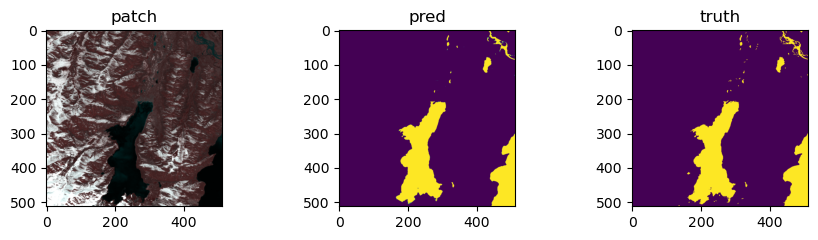

Ep621: tra-> Loss:0.026,Oa:0.985,Miou:0.960, val-> Loss:0.039,Oa:0.975, Miou:0.945,time:6.3s
Ep622: tra-> Loss:0.028,Oa:0.981,Miou:0.954,                                 time:3.7s
Ep623: tra-> Loss:0.026,Oa:0.984,Miou:0.960,                                 time:3.6s
Ep624: tra-> Loss:0.027,Oa:0.984,Miou:0.964, val-> Loss:0.053,Oa:0.974, Miou:0.940,time:6.3s
Ep625: tra-> Loss:0.028,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep626: tra-> Loss:0.030,Oa:0.981,Miou:0.958,                                 time:3.7s
Ep627: tra-> Loss:0.026,Oa:0.984,Miou:0.961, val-> Loss:0.041,Oa:0.975, Miou:0.942,time:6.3s
Ep628: tra-> Loss:0.029,Oa:0.983,Miou:0.959,                                 time:3.7s
Ep629: tra-> Loss:0.026,Oa:0.985,Miou:0.961,                                 time:3.6s
Ep630: tra-> Loss:0.026,Oa:0.984,Miou:0.958, val-> Loss:0.054,Oa:0.957, Miou:0.931,time:6.4s
Ep631: tra-> Loss:0.025,Oa:0.986,Miou:0.961,                                 time:3.7s
Ep632: tra-> Loss:0

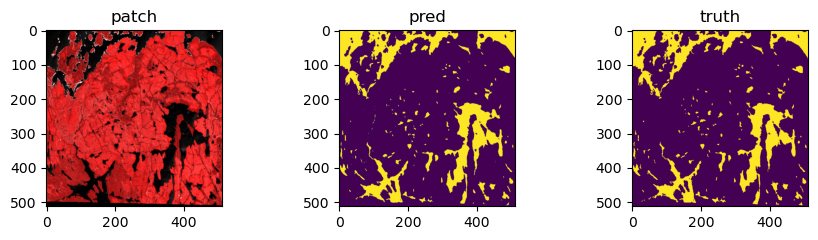

Ep641: tra-> Loss:0.025,Oa:0.984,Miou:0.961,                                 time:3.7s
Ep642: tra-> Loss:0.028,Oa:0.985,Miou:0.963, val-> Loss:0.037,Oa:0.980, Miou:0.948,time:6.4s
Ep643: tra-> Loss:0.029,Oa:0.974,Miou:0.946,                                 time:3.7s
Ep644: tra-> Loss:0.028,Oa:0.984,Miou:0.962,                                 time:3.7s
Ep645: tra-> Loss:0.027,Oa:0.984,Miou:0.959, val-> Loss:0.049,Oa:0.966, Miou:0.939,time:6.3s
Ep646: tra-> Loss:0.029,Oa:0.985,Miou:0.961,                                 time:3.8s
Ep647: tra-> Loss:0.026,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep648: tra-> Loss:0.027,Oa:0.984,Miou:0.959, val-> Loss:0.042,Oa:0.972, Miou:0.946,time:6.4s
Ep649: tra-> Loss:0.026,Oa:0.984,Miou:0.960,                                 time:3.7s
Ep650: tra-> Loss:0.025,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep651: tra-> Loss:0.029,Oa:0.984,Miou:0.959, val-> Loss:0.037,Oa:0.975, Miou:0.949,time:6.3s
Ep652: tra-> Loss:0

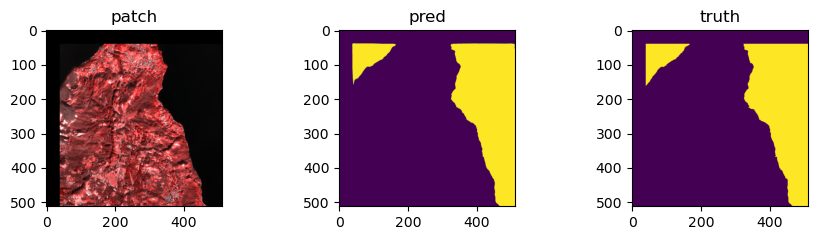

Ep661: tra-> Loss:0.024,Oa:0.984,Miou:0.960,                                 time:3.7s
Ep662: tra-> Loss:0.026,Oa:0.984,Miou:0.961,                                 time:3.7s
Ep663: tra-> Loss:0.024,Oa:0.986,Miou:0.962, val-> Loss:0.041,Oa:0.974, Miou:0.944,time:6.3s
Ep664: tra-> Loss:0.024,Oa:0.986,Miou:0.965,                                 time:3.6s
Ep665: tra-> Loss:0.026,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep666: tra-> Loss:0.025,Oa:0.984,Miou:0.961, val-> Loss:0.044,Oa:0.972, Miou:0.942,time:6.4s
Ep667: tra-> Loss:0.025,Oa:0.986,Miou:0.965,                                 time:3.6s
Ep668: tra-> Loss:0.027,Oa:0.984,Miou:0.960,                                 time:3.7s
Ep669: tra-> Loss:0.032,Oa:0.974,Miou:0.948, val-> Loss:0.054,Oa:0.968, Miou:0.936,time:6.4s
Ep670: tra-> Loss:0.031,Oa:0.982,Miou:0.949,                                 time:3.7s
Ep671: tra-> Loss:0.029,Oa:0.982,Miou:0.958,                                 time:3.7s
Ep672: tra-> Loss:0.026,O

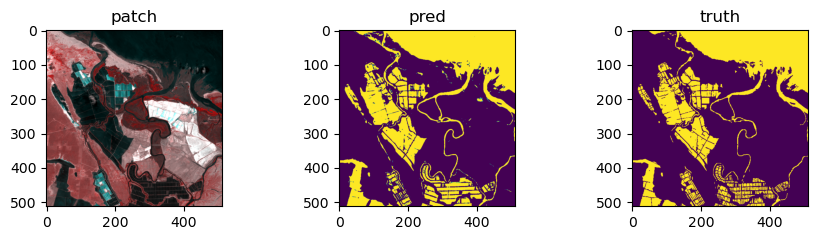

Ep681: tra-> Loss:0.025,Oa:0.986,Miou:0.962, val-> Loss:0.038,Oa:0.973, Miou:0.945,time:6.4s
Ep682: tra-> Loss:0.026,Oa:0.983,Miou:0.961,                                 time:3.8s
Ep683: tra-> Loss:0.025,Oa:0.985,Miou:0.960,                                 time:3.7s
Ep684: tra-> Loss:0.026,Oa:0.985,Miou:0.962, val-> Loss:0.040,Oa:0.973, Miou:0.943,time:6.4s
Ep685: tra-> Loss:0.026,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep686: tra-> Loss:0.026,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep687: tra-> Loss:0.025,Oa:0.985,Miou:0.961, val-> Loss:0.036,Oa:0.978, Miou:0.946,time:6.4s
Ep688: tra-> Loss:0.026,Oa:0.986,Miou:0.964,                                 time:3.7s
Ep689: tra-> Loss:0.024,Oa:0.985,Miou:0.963,                                 time:3.7s
Ep690: tra-> Loss:0.027,Oa:0.984,Miou:0.960, val-> Loss:0.039,Oa:0.973, Miou:0.947,time:6.5s
Ep691: tra-> Loss:0.024,Oa:0.985,Miou:0.965,                                 time:3.8s
Ep692: tra-> Loss:0

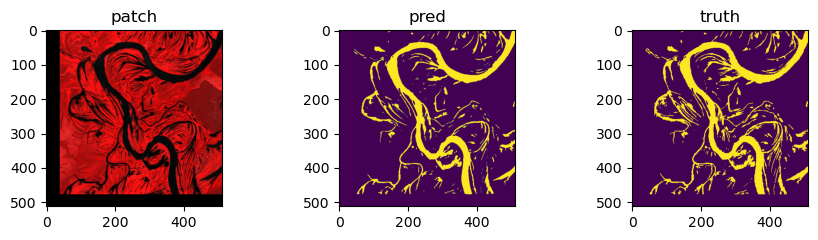

Ep701: tra-> Loss:0.025,Oa:0.983,Miou:0.956,                                 time:3.7s
Ep702: tra-> Loss:0.025,Oa:0.986,Miou:0.963, val-> Loss:0.039,Oa:0.975, Miou:0.944,time:6.4s
Ep703: tra-> Loss:0.025,Oa:0.984,Miou:0.962,                                 time:3.8s
Ep704: tra-> Loss:0.027,Oa:0.983,Miou:0.958,                                 time:3.7s
Ep705: tra-> Loss:0.026,Oa:0.986,Miou:0.964, val-> Loss:0.037,Oa:0.974, Miou:0.944,time:6.4s
Ep706: tra-> Loss:0.027,Oa:0.982,Miou:0.957,                                 time:3.7s
Ep707: tra-> Loss:0.029,Oa:0.984,Miou:0.959,                                 time:3.6s
Ep708: tra-> Loss:0.027,Oa:0.984,Miou:0.960, val-> Loss:0.041,Oa:0.974, Miou:0.947,time:6.4s
Ep709: tra-> Loss:0.025,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep710: tra-> Loss:0.027,Oa:0.984,Miou:0.961,                                 time:3.7s
Ep711: tra-> Loss:0.025,Oa:0.984,Miou:0.960, val-> Loss:0.040,Oa:0.973, Miou:0.943,time:6.4s
Ep712: tra-> Loss:0

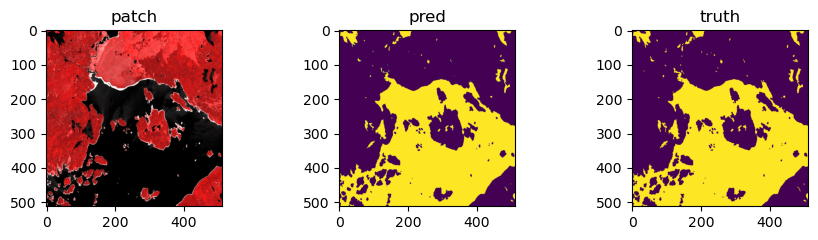

Ep721: tra-> Loss:0.026,Oa:0.984,Miou:0.959,                                 time:3.7s
Ep722: tra-> Loss:0.026,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep723: tra-> Loss:0.027,Oa:0.983,Miou:0.960, val-> Loss:0.049,Oa:0.969, Miou:0.935,time:6.5s
Ep724: tra-> Loss:0.025,Oa:0.984,Miou:0.957,                                 time:3.7s
Ep725: tra-> Loss:0.025,Oa:0.986,Miou:0.966,                                 time:3.7s
Ep726: tra-> Loss:0.026,Oa:0.984,Miou:0.962, val-> Loss:0.049,Oa:0.970, Miou:0.943,time:6.4s
Ep727: tra-> Loss:0.028,Oa:0.984,Miou:0.959,                                 time:3.8s
Ep728: tra-> Loss:0.024,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep729: tra-> Loss:0.024,Oa:0.986,Miou:0.965, val-> Loss:0.047,Oa:0.974, Miou:0.944,time:6.5s
Ep730: tra-> Loss:0.024,Oa:0.987,Miou:0.968,                                 time:3.9s
Ep731: tra-> Loss:0.026,Oa:0.983,Miou:0.961,                                 time:3.8s
Ep732: tra-> Loss:0.027,O

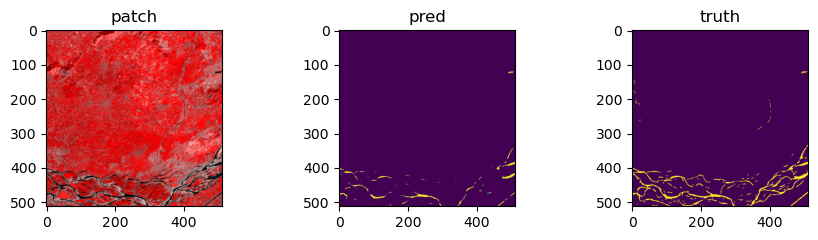

Ep741: tra-> Loss:0.025,Oa:0.984,Miou:0.959, val-> Loss:0.047,Oa:0.980, Miou:0.944,time:6.4s
Ep742: tra-> Loss:0.026,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep743: tra-> Loss:0.025,Oa:0.983,Miou:0.955,                                 time:3.7s
Ep744: tra-> Loss:0.023,Oa:0.985,Miou:0.963, val-> Loss:0.040,Oa:0.975, Miou:0.944,time:6.4s
Ep745: tra-> Loss:0.026,Oa:0.983,Miou:0.955,                                 time:3.7s
Ep746: tra-> Loss:0.023,Oa:0.985,Miou:0.965,                                 time:3.7s
Ep747: tra-> Loss:0.025,Oa:0.984,Miou:0.956, val-> Loss:0.042,Oa:0.973, Miou:0.944,time:6.3s
Ep748: tra-> Loss:0.024,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep749: tra-> Loss:0.027,Oa:0.985,Miou:0.963,                                 time:3.7s
Ep750: tra-> Loss:0.026,Oa:0.985,Miou:0.961, val-> Loss:0.043,Oa:0.976, Miou:0.943,time:6.4s
Ep751: tra-> Loss:0.024,Oa:0.984,Miou:0.962,                                 time:3.7s
Ep752: tra-> Loss:0

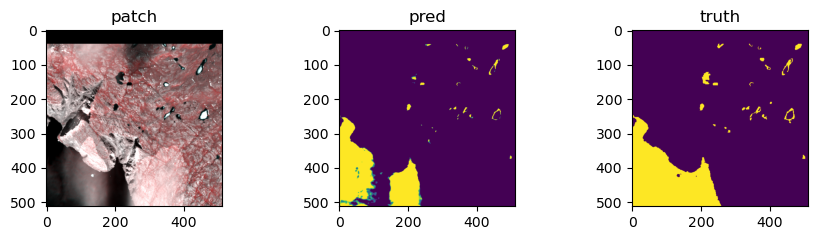

Ep761: tra-> Loss:0.024,Oa:0.986,Miou:0.964,                                 time:3.6s
Ep762: tra-> Loss:0.025,Oa:0.986,Miou:0.965, val-> Loss:0.044,Oa:0.970, Miou:0.943,time:6.3s
Ep763: tra-> Loss:0.023,Oa:0.985,Miou:0.963,                                 time:3.7s
Ep764: tra-> Loss:0.023,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep765: tra-> Loss:0.025,Oa:0.985,Miou:0.964, val-> Loss:0.039,Oa:0.975, Miou:0.945,time:6.4s
Ep766: tra-> Loss:0.023,Oa:0.981,Miou:0.957,                                 time:3.7s
Ep767: tra-> Loss:0.026,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep768: tra-> Loss:0.025,Oa:0.986,Miou:0.963, val-> Loss:0.045,Oa:0.977, Miou:0.944,time:6.4s
Ep769: tra-> Loss:0.026,Oa:0.982,Miou:0.957,                                 time:3.7s
Ep770: tra-> Loss:0.025,Oa:0.986,Miou:0.962,                                 time:3.7s
Ep771: tra-> Loss:0.027,Oa:0.983,Miou:0.960, val-> Loss:0.042,Oa:0.977, Miou:0.941,time:6.4s
Ep772: tra-> Loss:0

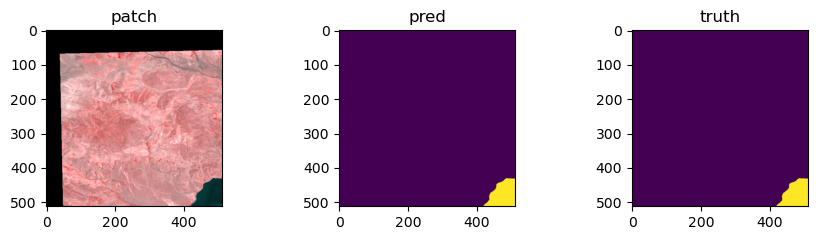

Ep781: tra-> Loss:0.025,Oa:0.986,Miou:0.966,                                 time:3.8s
Ep782: tra-> Loss:0.027,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep783: tra-> Loss:0.029,Oa:0.981,Miou:0.958, val-> Loss:0.050,Oa:0.967, Miou:0.940,time:6.4s
Ep784: tra-> Loss:0.026,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep785: tra-> Loss:0.030,Oa:0.976,Miou:0.949,                                 time:3.8s
Ep786: tra-> Loss:0.026,Oa:0.982,Miou:0.959, val-> Loss:0.042,Oa:0.970, Miou:0.939,time:6.3s
Ep787: tra-> Loss:0.025,Oa:0.983,Miou:0.957,                                 time:3.8s
Ep788: tra-> Loss:0.024,Oa:0.987,Miou:0.965,                                 time:3.7s
Ep789: tra-> Loss:0.023,Oa:0.986,Miou:0.964, val-> Loss:0.049,Oa:0.967, Miou:0.939,time:6.4s
Ep790: tra-> Loss:0.026,Oa:0.984,Miou:0.962,                                 time:3.7s
Ep791: tra-> Loss:0.026,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep792: tra-> Loss:0.023,O

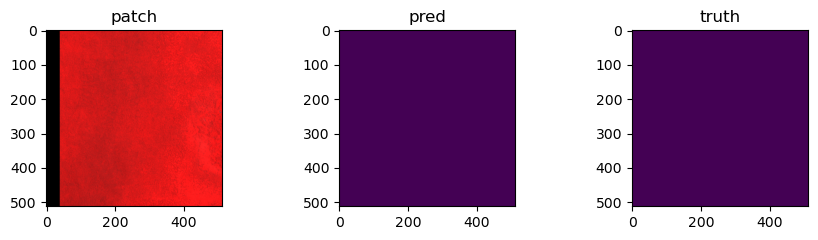

Ep801: tra-> Loss:0.025,Oa:0.985,Miou:0.963, val-> Loss:0.050,Oa:0.967, Miou:0.940,time:6.5s
Ep802: tra-> Loss:0.026,Oa:0.986,Miou:0.965,                                 time:3.7s
Ep803: tra-> Loss:0.026,Oa:0.986,Miou:0.966,                                 time:3.9s
Ep804: tra-> Loss:0.024,Oa:0.981,Miou:0.956, val-> Loss:0.047,Oa:0.973, Miou:0.943,time:6.4s
Ep805: tra-> Loss:0.024,Oa:0.986,Miou:0.964,                                 time:3.7s
Ep806: tra-> Loss:0.025,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep807: tra-> Loss:0.025,Oa:0.986,Miou:0.963, val-> Loss:0.048,Oa:0.970, Miou:0.939,time:6.4s
Ep808: tra-> Loss:0.026,Oa:0.984,Miou:0.960,                                 time:3.7s
Ep809: tra-> Loss:0.023,Oa:0.987,Miou:0.965,                                 time:3.6s
Ep810: tra-> Loss:0.023,Oa:0.986,Miou:0.964, val-> Loss:0.044,Oa:0.969, Miou:0.941,time:6.4s
Ep811: tra-> Loss:0.023,Oa:0.987,Miou:0.967,                                 time:3.8s
Ep812: tra-> Loss:0

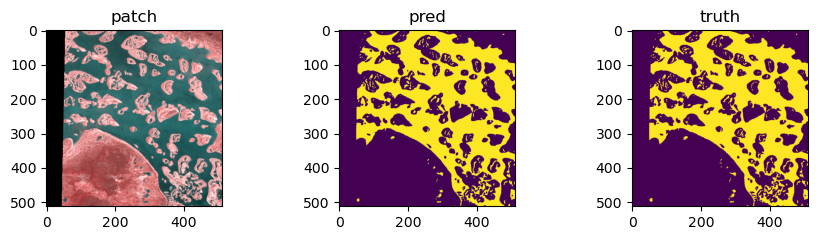

Ep821: tra-> Loss:0.026,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep822: tra-> Loss:0.024,Oa:0.984,Miou:0.958, val-> Loss:0.042,Oa:0.972, Miou:0.942,time:6.4s
Ep823: tra-> Loss:0.025,Oa:0.986,Miou:0.965,                                 time:3.7s
Ep824: tra-> Loss:0.024,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep825: tra-> Loss:0.023,Oa:0.987,Miou:0.967, val-> Loss:0.046,Oa:0.968, Miou:0.942,time:6.3s
Ep826: tra-> Loss:0.024,Oa:0.985,Miou:0.964,                                 time:3.7s
Ep827: tra-> Loss:0.025,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep828: tra-> Loss:0.023,Oa:0.986,Miou:0.966, val-> Loss:0.043,Oa:0.969, Miou:0.939,time:6.4s
Ep829: tra-> Loss:0.024,Oa:0.986,Miou:0.962,                                 time:3.7s
Ep830: tra-> Loss:0.025,Oa:0.985,Miou:0.963,                                 time:3.7s
Ep831: tra-> Loss:0.025,Oa:0.986,Miou:0.964, val-> Loss:0.047,Oa:0.971, Miou:0.941,time:6.4s
Ep832: tra-> Loss:0

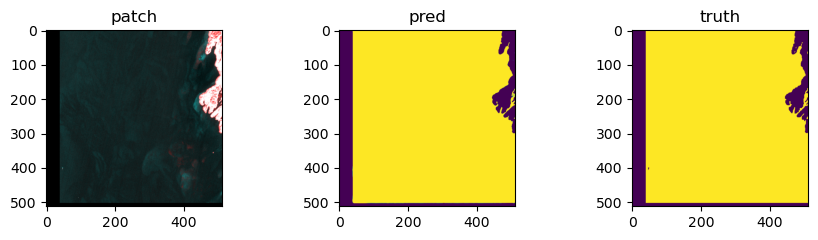

Ep841: tra-> Loss:0.023,Oa:0.986,Miou:0.964,                                 time:3.8s
Ep842: tra-> Loss:0.026,Oa:0.984,Miou:0.962,                                 time:3.7s
Ep843: tra-> Loss:0.023,Oa:0.986,Miou:0.964, val-> Loss:0.043,Oa:0.969, Miou:0.944,time:6.4s
Ep844: tra-> Loss:0.024,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep845: tra-> Loss:0.024,Oa:0.986,Miou:0.964,                                 time:3.7s
Ep846: tra-> Loss:0.025,Oa:0.986,Miou:0.964, val-> Loss:0.048,Oa:0.968, Miou:0.942,time:6.4s
Ep847: tra-> Loss:0.024,Oa:0.985,Miou:0.962,                                 time:3.6s
Ep848: tra-> Loss:0.023,Oa:0.987,Miou:0.968,                                 time:3.7s
Ep849: tra-> Loss:0.023,Oa:0.986,Miou:0.963, val-> Loss:0.043,Oa:0.973, Miou:0.946,time:6.4s
Ep850: tra-> Loss:0.024,Oa:0.984,Miou:0.959,                                 time:3.7s
Ep851: tra-> Loss:0.024,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep852: tra-> Loss:0.023,O

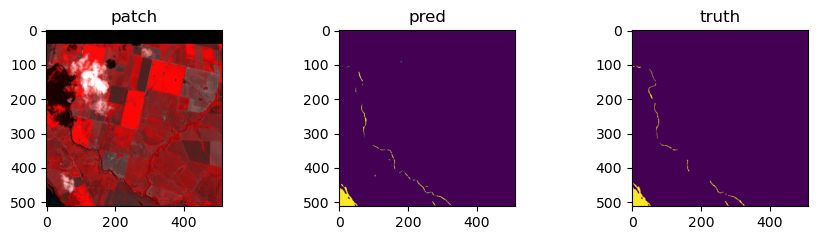

Ep861: tra-> Loss:0.024,Oa:0.987,Miou:0.966, val-> Loss:0.045,Oa:0.972, Miou:0.940,time:6.4s
Ep862: tra-> Loss:0.024,Oa:0.987,Miou:0.966,                                 time:3.7s
Ep863: tra-> Loss:0.024,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep864: tra-> Loss:0.025,Oa:0.985,Miou:0.964, val-> Loss:0.038,Oa:0.976, Miou:0.948,time:6.3s
Ep865: tra-> Loss:0.027,Oa:0.985,Miou:0.963,                                 time:3.7s
Ep866: tra-> Loss:0.023,Oa:0.986,Miou:0.964,                                 time:3.6s
Ep867: tra-> Loss:0.023,Oa:0.987,Miou:0.965, val-> Loss:0.039,Oa:0.973, Miou:0.946,time:6.4s
Ep868: tra-> Loss:0.025,Oa:0.985,Miou:0.965,                                 time:3.6s
Ep869: tra-> Loss:0.024,Oa:0.986,Miou:0.964,                                 time:3.6s
Ep870: tra-> Loss:0.025,Oa:0.986,Miou:0.963, val-> Loss:0.034,Oa:0.979, Miou:0.947,time:6.3s
Ep871: tra-> Loss:0.024,Oa:0.985,Miou:0.961,                                 time:3.7s
Ep872: tra-> Loss:0

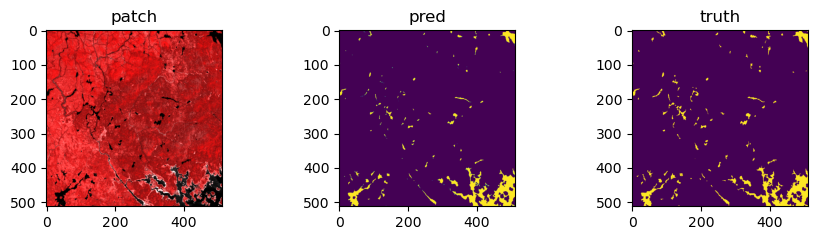

Ep881: tra-> Loss:0.025,Oa:0.985,Miou:0.964,                                 time:3.7s
Ep882: tra-> Loss:0.022,Oa:0.984,Miou:0.962, val-> Loss:0.038,Oa:0.975, Miou:0.948,time:6.4s
Ep883: tra-> Loss:0.023,Oa:0.986,Miou:0.963,                                 time:3.7s
Ep884: tra-> Loss:0.024,Oa:0.983,Miou:0.960,                                 time:3.7s
Ep885: tra-> Loss:0.025,Oa:0.984,Miou:0.958, val-> Loss:0.036,Oa:0.980, Miou:0.949,time:6.4s
Ep886: tra-> Loss:0.022,Oa:0.986,Miou:0.967,                                 time:3.7s
Ep887: tra-> Loss:0.025,Oa:0.986,Miou:0.964,                                 time:3.6s
Ep888: tra-> Loss:0.024,Oa:0.986,Miou:0.964, val-> Loss:0.038,Oa:0.976, Miou:0.948,time:6.3s
Ep889: tra-> Loss:0.023,Oa:0.984,Miou:0.961,                                 time:3.6s
Ep890: tra-> Loss:0.023,Oa:0.986,Miou:0.961,                                 time:3.6s
Ep891: tra-> Loss:0.023,Oa:0.986,Miou:0.964, val-> Loss:0.036,Oa:0.980, Miou:0.948,time:6.3s
Ep892: tra-> Loss:0

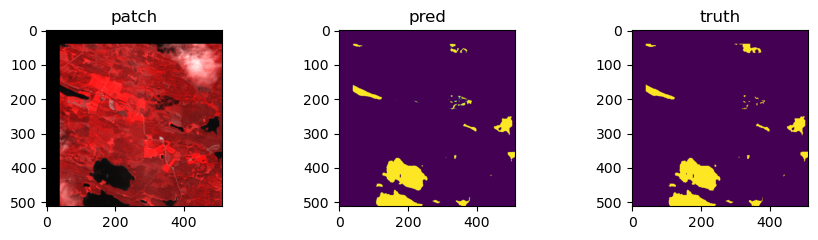

Ep901: tra-> Loss:0.029,Oa:0.983,Miou:0.955,                                 time:3.7s
Ep902: tra-> Loss:0.025,Oa:0.986,Miou:0.965,                                 time:3.7s
Ep903: tra-> Loss:0.023,Oa:0.987,Miou:0.966, val-> Loss:0.042,Oa:0.974, Miou:0.943,time:6.4s
Ep904: tra-> Loss:0.026,Oa:0.984,Miou:0.960,                                 time:3.7s
Ep905: tra-> Loss:0.023,Oa:0.985,Miou:0.963,                                 time:3.7s
Ep906: tra-> Loss:0.025,Oa:0.987,Miou:0.966, val-> Loss:0.038,Oa:0.976, Miou:0.947,time:6.4s
Ep907: tra-> Loss:0.025,Oa:0.985,Miou:0.963,                                 time:3.6s
Ep908: tra-> Loss:0.025,Oa:0.984,Miou:0.963,                                 time:3.7s
Ep909: tra-> Loss:0.025,Oa:0.983,Miou:0.958, val-> Loss:0.041,Oa:0.976, Miou:0.946,time:6.3s
Ep910: tra-> Loss:0.023,Oa:0.987,Miou:0.965,                                 time:3.6s
Ep911: tra-> Loss:0.025,Oa:0.986,Miou:0.964,                                 time:3.6s
Ep912: tra-> Loss:0.025,O

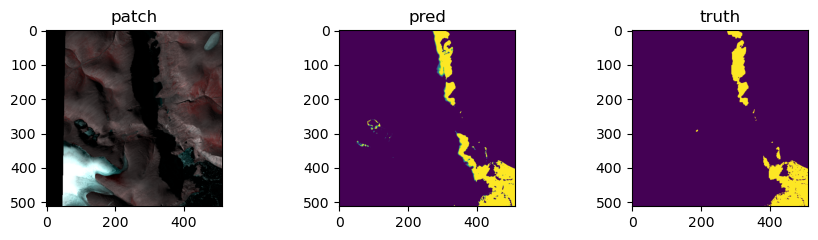

Ep921: tra-> Loss:0.029,Oa:0.975,Miou:0.953, val-> Loss:0.063,Oa:0.976, Miou:0.938,time:6.4s
Ep922: tra-> Loss:0.026,Oa:0.982,Miou:0.960,                                 time:3.7s
Ep923: tra-> Loss:0.025,Oa:0.985,Miou:0.962,                                 time:3.7s
Ep924: tra-> Loss:0.024,Oa:0.986,Miou:0.965, val-> Loss:0.042,Oa:0.975, Miou:0.948,time:6.4s
Ep925: tra-> Loss:0.023,Oa:0.987,Miou:0.965,                                 time:3.7s
Ep926: tra-> Loss:0.023,Oa:0.987,Miou:0.967,                                 time:3.7s
Ep927: tra-> Loss:0.023,Oa:0.986,Miou:0.967, val-> Loss:0.050,Oa:0.964, Miou:0.939,time:6.4s
Ep928: tra-> Loss:0.025,Oa:0.984,Miou:0.960,                                 time:3.7s
Ep929: tra-> Loss:0.029,Oa:0.983,Miou:0.959,                                 time:3.8s
Ep930: tra-> Loss:0.023,Oa:0.988,Miou:0.965, val-> Loss:0.041,Oa:0.974, Miou:0.948,time:6.4s
Ep931: tra-> Loss:0.025,Oa:0.986,Miou:0.965,                                 time:3.7s
Ep932: tra-> Loss:0

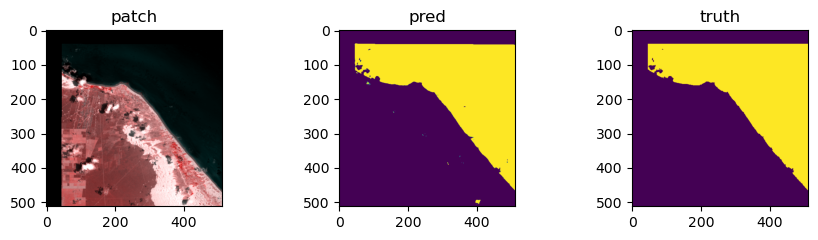

Ep941: tra-> Loss:0.024,Oa:0.986,Miou:0.964,                                 time:3.7s
Ep942: tra-> Loss:0.026,Oa:0.985,Miou:0.963, val-> Loss:0.040,Oa:0.973, Miou:0.946,time:6.4s
Ep943: tra-> Loss:0.022,Oa:0.985,Miou:0.965,                                 time:3.7s
Ep944: tra-> Loss:0.024,Oa:0.986,Miou:0.966,                                 time:3.7s
Ep945: tra-> Loss:0.021,Oa:0.988,Miou:0.968, val-> Loss:0.039,Oa:0.975, Miou:0.946,time:6.5s
Ep946: tra-> Loss:0.026,Oa:0.986,Miou:0.964,                                 time:3.7s
Ep947: tra-> Loss:0.023,Oa:0.985,Miou:0.964,                                 time:3.7s
Ep948: tra-> Loss:0.024,Oa:0.986,Miou:0.965, val-> Loss:0.046,Oa:0.968, Miou:0.942,time:6.4s
Ep949: tra-> Loss:0.024,Oa:0.987,Miou:0.966,                                 time:3.7s
Ep950: tra-> Loss:0.024,Oa:0.985,Miou:0.962,                                 time:3.8s
Ep951: tra-> Loss:0.023,Oa:0.987,Miou:0.968, val-> Loss:0.046,Oa:0.968, Miou:0.943,time:6.4s
Ep952: tra-> Loss:0

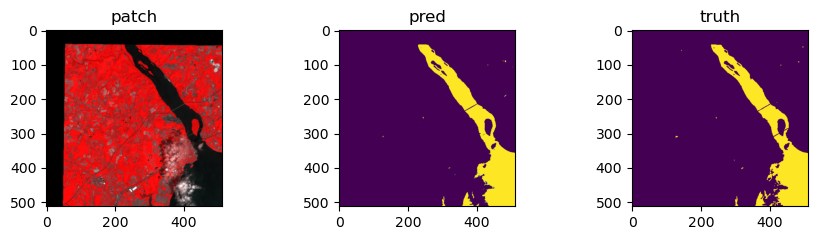

Ep961: tra-> Loss:0.023,Oa:0.987,Miou:0.965,                                 time:3.7s
Ep962: tra-> Loss:0.025,Oa:0.985,Miou:0.963,                                 time:3.7s
Ep963: tra-> Loss:0.023,Oa:0.987,Miou:0.966, val-> Loss:0.052,Oa:0.965, Miou:0.937,time:6.4s
Ep964: tra-> Loss:0.024,Oa:0.986,Miou:0.964,                                 time:3.7s
Ep965: tra-> Loss:0.025,Oa:0.985,Miou:0.960,                                 time:3.8s
Ep966: tra-> Loss:0.025,Oa:0.984,Miou:0.959, val-> Loss:0.044,Oa:0.970, Miou:0.940,time:6.4s
Ep967: tra-> Loss:0.023,Oa:0.986,Miou:0.965,                                 time:3.7s
Ep968: tra-> Loss:0.025,Oa:0.984,Miou:0.962,                                 time:3.7s
Ep969: tra-> Loss:0.025,Oa:0.985,Miou:0.965, val-> Loss:0.039,Oa:0.974, Miou:0.944,time:6.4s
Ep970: tra-> Loss:0.024,Oa:0.986,Miou:0.965,                                 time:3.7s
Ep971: tra-> Loss:0.024,Oa:0.984,Miou:0.962,                                 time:3.7s
Ep972: tra-> Loss:0.023,O

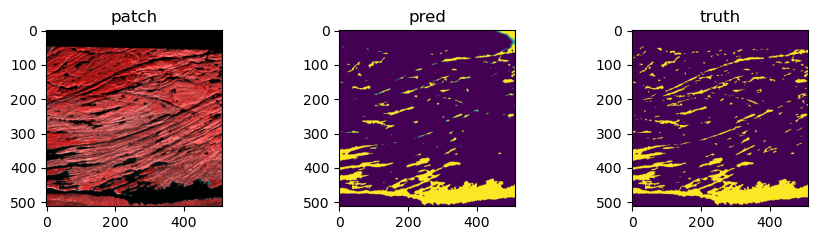

Ep981: tra-> Loss:0.025,Oa:0.985,Miou:0.966, val-> Loss:0.045,Oa:0.971, Miou:0.944,time:6.4s
Ep982: tra-> Loss:0.024,Oa:0.987,Miou:0.966,                                 time:3.7s
Ep983: tra-> Loss:0.023,Oa:0.986,Miou:0.963,                                 time:3.8s
Ep984: tra-> Loss:0.023,Oa:0.984,Miou:0.961, val-> Loss:0.046,Oa:0.971, Miou:0.943,time:6.4s
Ep985: tra-> Loss:0.025,Oa:0.984,Miou:0.959,                                 time:3.7s
Ep986: tra-> Loss:0.023,Oa:0.986,Miou:0.965,                                 time:3.7s
Ep987: tra-> Loss:0.024,Oa:0.985,Miou:0.964, val-> Loss:0.043,Oa:0.973, Miou:0.943,time:6.5s
Ep988: tra-> Loss:0.026,Oa:0.983,Miou:0.960,                                 time:3.8s
Ep989: tra-> Loss:0.023,Oa:0.986,Miou:0.965,                                 time:3.7s
Ep990: tra-> Loss:0.021,Oa:0.987,Miou:0.966, val-> Loss:0.039,Oa:0.972, Miou:0.944,time:6.4s
Ep991: tra-> Loss:0.024,Oa:0.986,Miou:0.965,                                 time:3.7s
Ep992: tra-> Loss:0

In [10]:
device = torch.device('cuda:0') 
metrics = train_loops(model=model, 
                epoches=1000,  
                loss_fn=criterion,  
                optimizer=optimizer,  
                tra_loader=tra_loader,  
                val_loader=val_loader,  
                # lr_scheduler=lr_scheduler,  
                device=device)  


In [11]:
## model saving 
# model_name = 'unet_att'  ## model name setting for saving   
# date_str = time.strftime("%Y-%m-%d-%H",   time.localtime())      
# date_str = date_str.replace('-', '')  ## remove '-' for file name    
# path_save = f'model/trained/{model_name}_weights_{date_str}.pth'   
# torch.save(model.state_dict(), path_save)     ## save weights of the trained model   
# # # model.load_state_dict(torch.load(path_save, weights_only=True))  ## load the weights of the trained model  
# # # ## metrics saving   
# path_metrics = f'model/trained/{model_name}_metrics_{date_str}.csv'    
# # path_metrics = f'model/trained/patch_{patch_size}/{model_name}_metrics_1.csv'    
# metrics_df = pd.DataFrame(metrics)  
# metrics_df.to_csv(path_metrics, index=False, sep=',')   
